# Financial Loan Risk Prediction

## Summative Machine Learning Lab

**Student:** Bryan Anunda

**Course:** Data Science

**Framework:** CRISP-DM

**Objective:** Develop a machine learning model to support loan approval decisions by predicting applicant risk using historical financial data.

<div align="center">

![Banner/header image](Data/Raw%20data/images.jpg)

</div>


## Overview

This notebook presents a complete CRISP-DM machine learning pipeline for FinTech Innovations' loan approval process. Using a dataset of 20,000 historical loan applications, a Random Forest classifier was developed to predict loan approval outcomes. 

The final optimised model achieved a test ROC-AUC of 0.9793 and an F1-score of 0.86 on the approved-loan class, correctly identifying 792 of 956 creditworthy applicants while limiting costly false approvals to 101 cases. Deploying the model is estimated to limit total financial exposure to $6.36 million per 4,000 decisions versus unconstrained manual review, and top predictors — Debt-to-Income Ratio, Annual Income, and Interest Rate — provide actionable intelligence for loan officers.

## 1. Business Understanding



#### 1.1 Business Context

FinTech Innovations currently relies on manual loan reviews conducted by loan officers. This process is time-consuming, inconsistent, and may overlook patterns in historical lending data. The primary stakeholders include loan officers, management, applicants, and regulators, all of whom require accurate, fair, and explainable lending decisions.

Model errors have different business impacts. Approving a high-risk applicant (False Positive) may result in an average loss of **$50,000**, while rejecting a creditworthy applicant (False Negative) results in an estimated lost profit of **$8,000**. Since the objective is to determine whether a loan should be approved or rejected, this project is formulated as a **binary classification** problem rather than a regression problem.

Classification vs. Regression: A binary classification approach is selected because the business objective is a discrete approve/reject decision. A regression risk-score could also support officers, but it requires a secondary threshold-setting step. Classification directly produces the actionable output that the approval workflow requires.


#### 2. Modeling Goals and Success Criteria

The objective is to develop a classification model that supports accurate and consistent loan approval decisions while minimizing financial risk.

The model will be evaluated using  **Precision**, **Recall**, **F1-Score**, and **ROC-AUC**, as these metrics provide a balanced assessment for an imbalanced classification problem. A business cost metric based on the financial impact of False Positives (**$50,000**) and False Negatives (**$8,000**) will also be used during the final evaluation.

The model will be considered successful if it demonstrates strong cross-validation performance, generalizes well to unseen data, and reduces the expected financial cost of incorrect lending decisions compared to a baseline model.

Baseline performance targets:

- ROC-AUC ≥ 0.90 (well above a random classifier baseline of 0.50)
- F1-Score (Approved class) ≥ 0.80
- Business cost lower than the cost under a naïve 'approve all' policy (which incurs $50,000 per class-0 applicant)

N|B: Accuracy is explicitly not the primary metric because the dataset is class-imbalanced (approximately 76% rejected, 24% approved); a model that rejects every applicant would achieve 76% accuracy while being completely useless.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


#### 3. Exploratory Data Analysis (EDA)

The objective of this section is to understand the dataset before model development by examining its structure, feature distributions, relationships between variables, and potential data quality issues. These insights guide preprocessing decisions and feature engineering in later stages.

##### 3.1 Importation of Libraries and Loading dataset

In [324]:
#Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      cross_validate, StratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, StandardScaler,
                                    OrdinalEncoder)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import joblib

##### 3.2 Preview Dataset

In [274]:
#load data
df = pd.read_csv("Data\\Raw Data\\financial_loan_data.csv")

In [275]:
#first 5 rows of the dataset
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [276]:
#last 5 rows of the dataset
df.tail()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
19995,44,"$30,180.00",587,Employed,High School,19,24521,36,Married,3,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,56,"$49,246.00",567,Employed,Associate,33,25818,36,Married,5,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,44,"$48,958.00",645,Employed,Bachelor,20,37033,72,Married,3,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,60,"$41,025.00",560,Employed,NaN,36,14760,72,NaN,3,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0
19999,20,"$53,227.00",574,Employed,Associate,0,32055,48,Married,0,...,4435.583333,0.853801,5,41372,0.240055,0.242693,1049.830407,0.298006,0,59.0


In [277]:
#sample 5 rows of the dataset
df.sample(5, random_state=42)

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
10650,37,"$100,761.00",604,Employed,High School,16,28479,84,Single,0,...,8396.750000,0.809983,7,7304,0.251479,0.222397,671.369324,0.090436,1,41.6
2041,35,"$189,154.00",509,Employed,High School,11,11222,60,Married,2,...,15762.833333,0.831507,7,22443,0.261722,0.270451,342.970300,0.047832,1,38.4
8668,44,"$73,272.00",483,Employed,High School,20,31573,48,Widowed,0,...,6106.000000,0.800830,1,20044,0.285073,0.342088,1215.387601,0.271436,0,53.0
1114,41,"$57,115.00",412,Employed,Master,20,21937,12,Married,3,...,4759.583333,0.954407,5,1714,0.280937,0.280613,2117.710361,0.530868,0,50.0
13902,39,"$61,155.00",551,Employed,Master,19,31510,48,Divorced,0,...,5096.250000,0.840267,3,55941,0.251010,0.250815,1046.213156,0.309877,0,51.0


##### 3.3 Dataset Shape

In [278]:
#Dataset shape
print(f"Rows: {df.shape[0]} , Columns: {df.shape[1]}")

Rows: 20000 , Columns: 35


**Observation:** 

Observation: The dataset contains 20,000 observations and 35 features, providing a large and rich sample for supervised learning. 


##### 3.4 Dataset Information

In [279]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

**Observation:** 

The dataset contains a mixture of numerical (int64/float64) and categorical (string) features. `AnnualIncome` required cleaning from a currency-formatted string. Three columns contain missing values: `EducationLevel`, `MaritalStatus`, and `SavingsAccountBalance`. All others are fully populated.


In [280]:
# Fix AnnualIncome: strip '$' and ',' formatting, convert to float
df['AnnualIncome'] = df['AnnualIncome'].str.replace(r'[\$,]', '', regex=True).astype(float)

# Convert string-typed categorical columns to Python str for sklearn compatibility
cat_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
            'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
for col in cat_cols:
    df[col] = df[col].astype(str).replace('nan', np.nan)


##### 3.5 Summary Statistics

In [281]:
#statistics
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


**Observation:** 

Numerical features such as `AnnualIncome`, `LoanAmount`, and `NetWorth` show wide ranges and large standard deviations, indicating diverse applicant profiles. Some variables (e.g., `SavingsAccountBalance`, `NetWorth`) include near-zero or negative values, suggesting variation in financial health. These characteristics justify scaling and careful outlier inspection.


##### 3.6 Missing Values

In [282]:
#missing values - filter only columns with missing values
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0')
print(missing_summary)

                       Missing Count  Missing %
EducationLevel                   901       4.50
MaritalStatus                   1331       6.65
SavingsAccountBalance            572       2.86


**Observation:** 

Three features contain missing values: `EducationLevel` (~4.5%), `MaritalStatus` (~6.7%), and `SavingsAccountBalance` (~2.9%). These rates are moderate and manageable through imputation. Removing affected rows would discard ~14% of training data and is not recommended.



##### 3.7 Duplicate Records

In [283]:
print(f'Duplicate rows: {df.duplicated().sum()}')


Duplicate rows: 0


**Observation:** 

No duplicate records were detected. Each row represents a unique loan application, so no removal step is required.

##### 3.8 Target Distribution

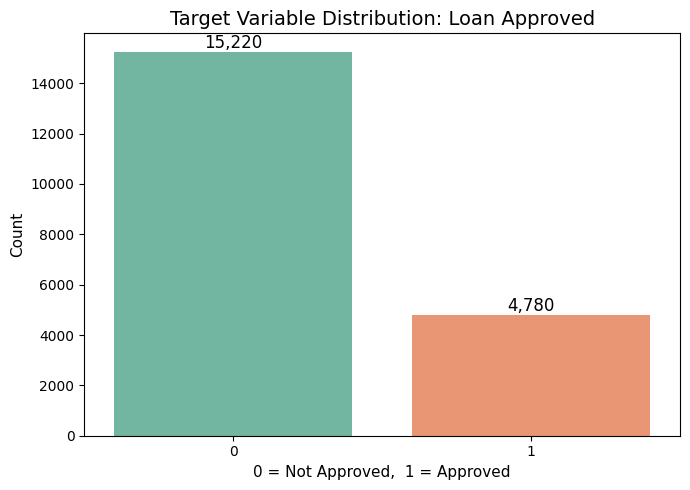

LoanApproved
0    15220
1     4780
Name: count, dtype: int64
Imbalance ratio: 3.18:1  (Not Approved : Approved)


<Figure size 640x480 with 0 Axes>

In [284]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='LoanApproved', hue='LoanApproved',
                   palette='Set2', legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.title('Target Variable Distribution: Loan Approved', fontsize=14)
plt.xlabel('0 = Not Approved,  1 = Approved', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.tight_layout()
plt.show()
print(df['LoanApproved'].value_counts())
print(f'Imbalance ratio: {15220/4780:.2f}:1  (Not Approved : Approved)')
#save the plot as an image
plt.savefig('EDA charts\\Target_Distribution.png', dpi=300, bbox_inches='tight')

**Observation:** 

target variable = 'LoanApproved'

The target variable is **imbalanced** — 15,220 rejected (76.1%) vs 4,780 approved (23.9%), a ratio of roughly **3.2:1**. This imbalance means accuracy alone is a misleading metric; ROC-AUC and F1-score are more appropriate. Models will use `class_weight='balanced'` to compensate.

##### 3.9 Numerical Feature Distributions

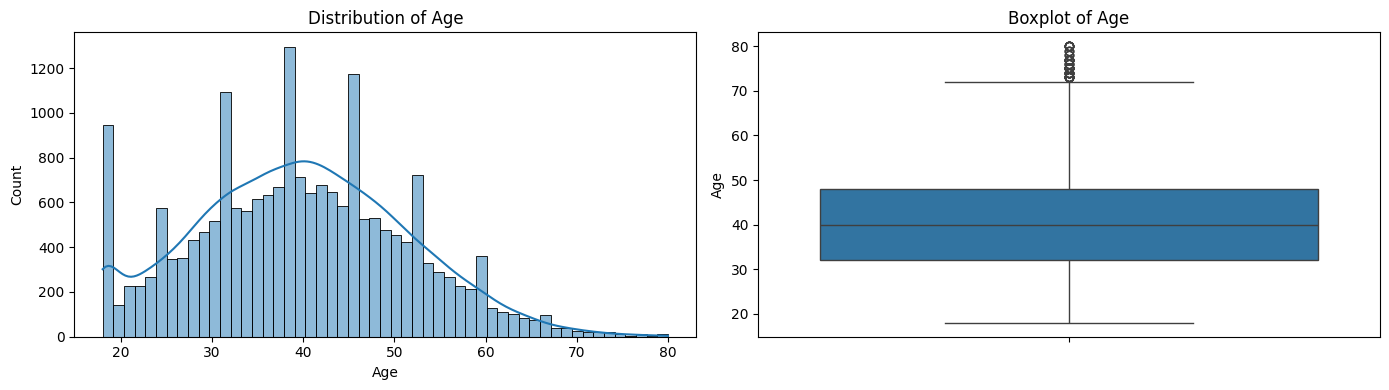

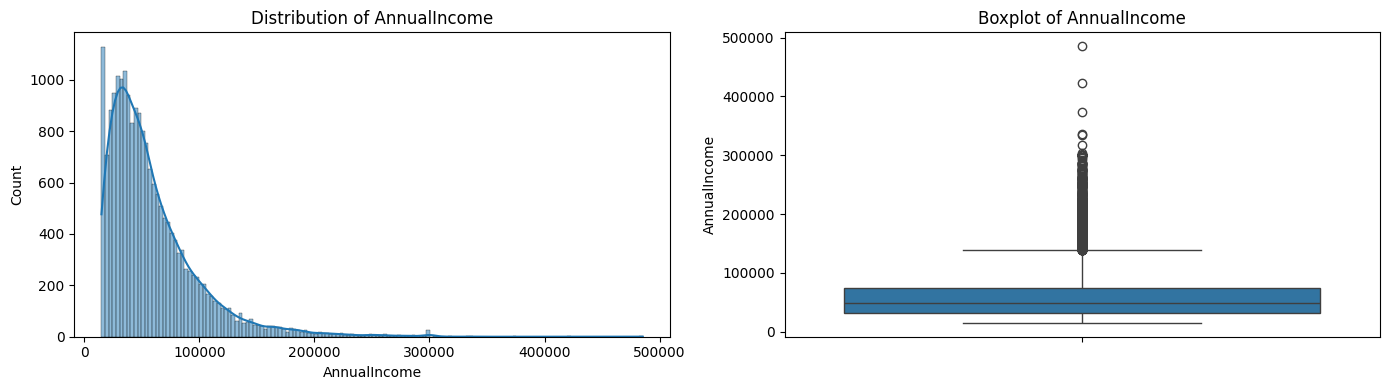

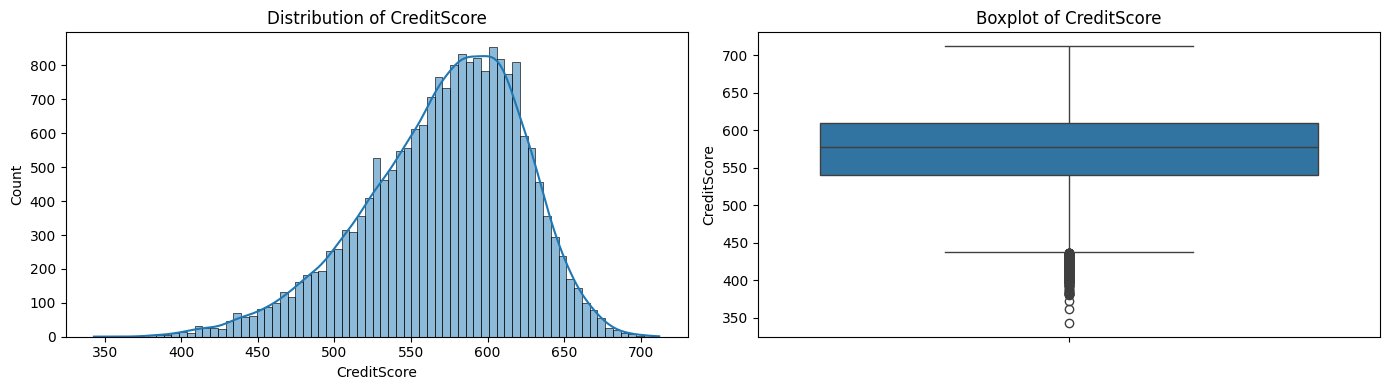

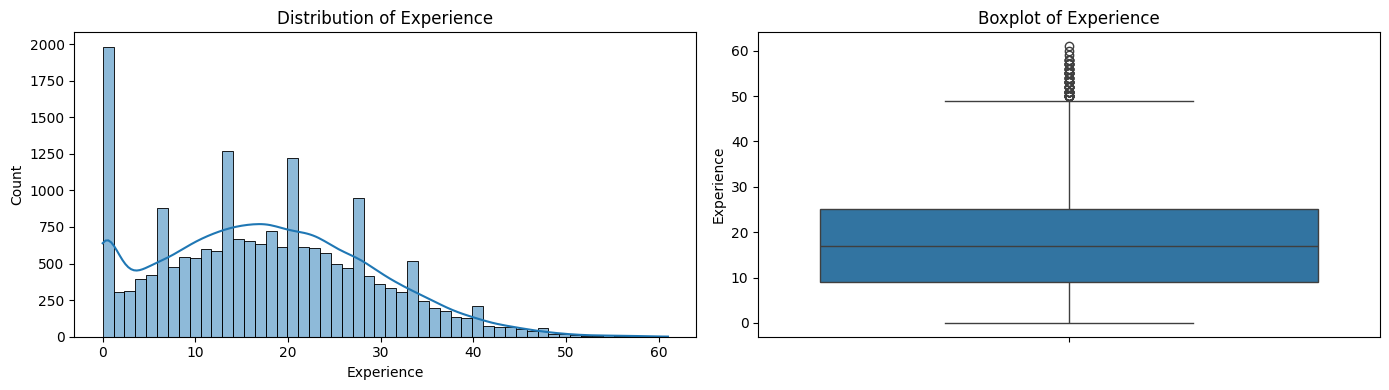

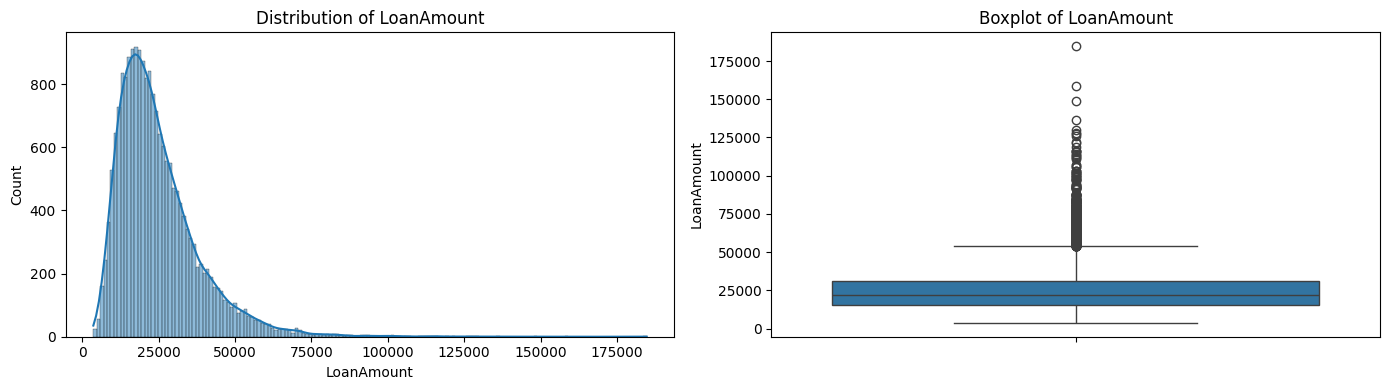

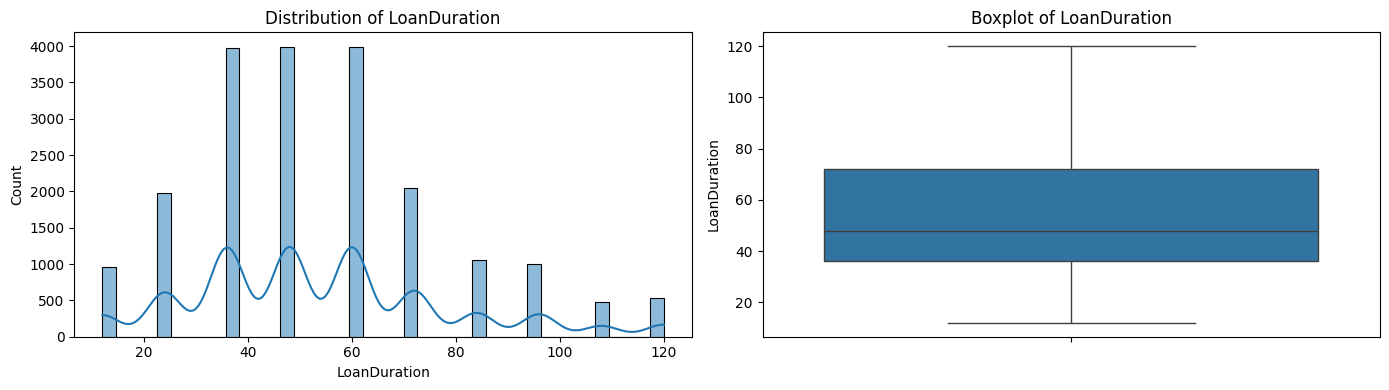

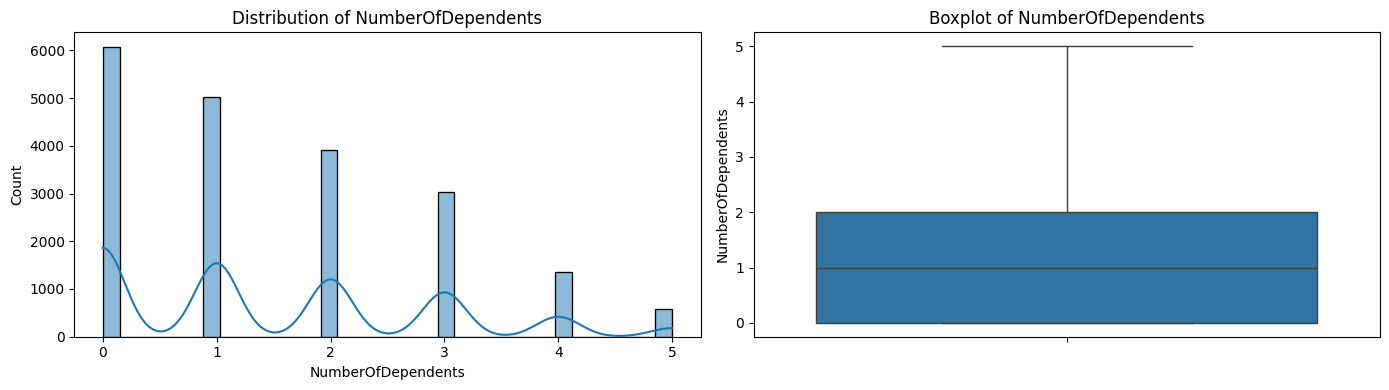

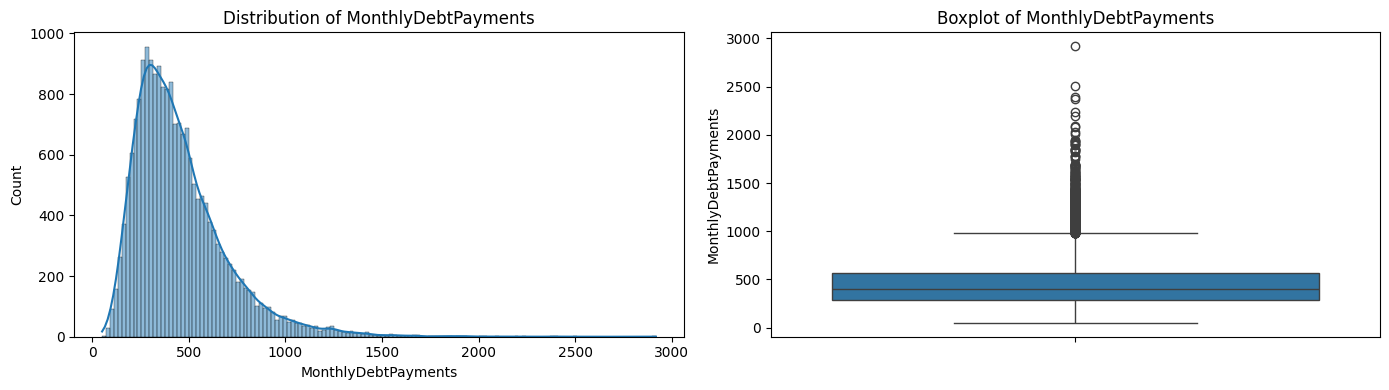

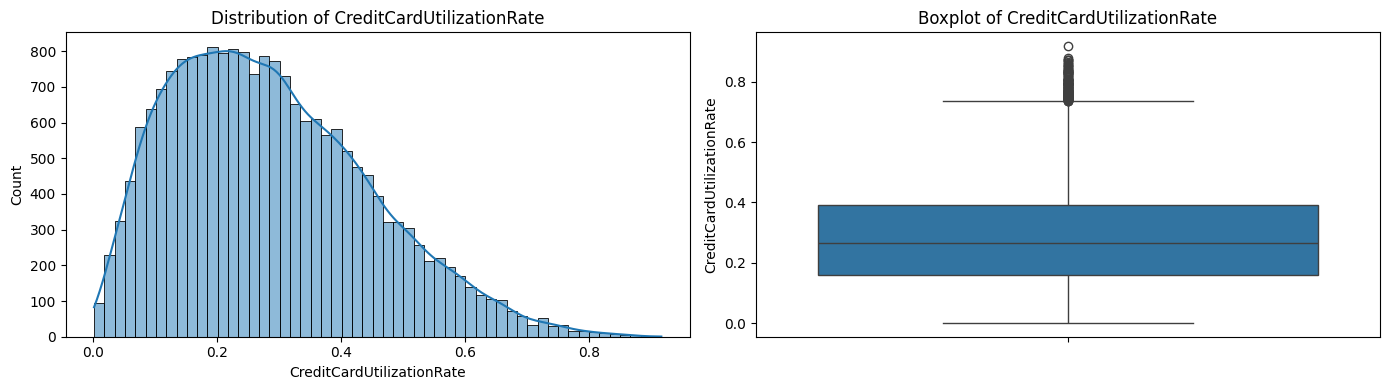

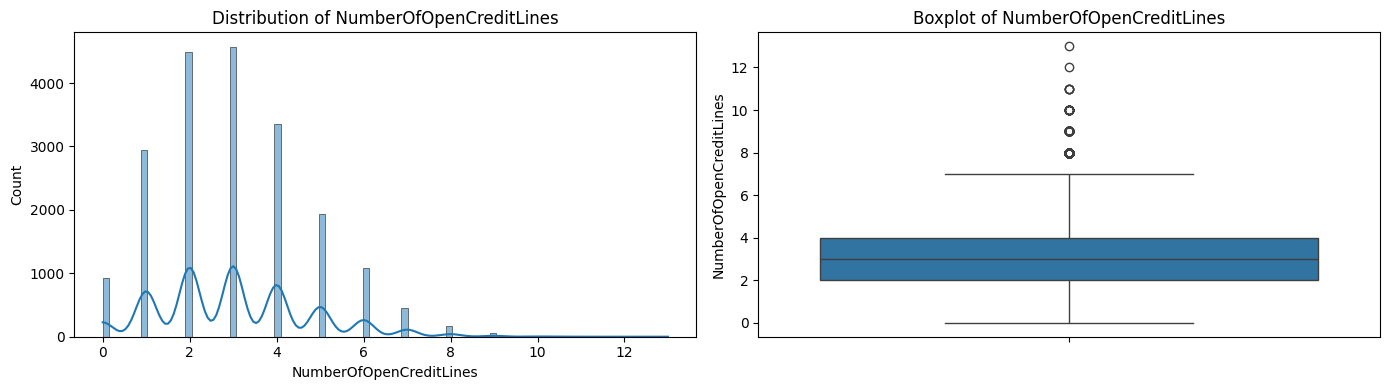

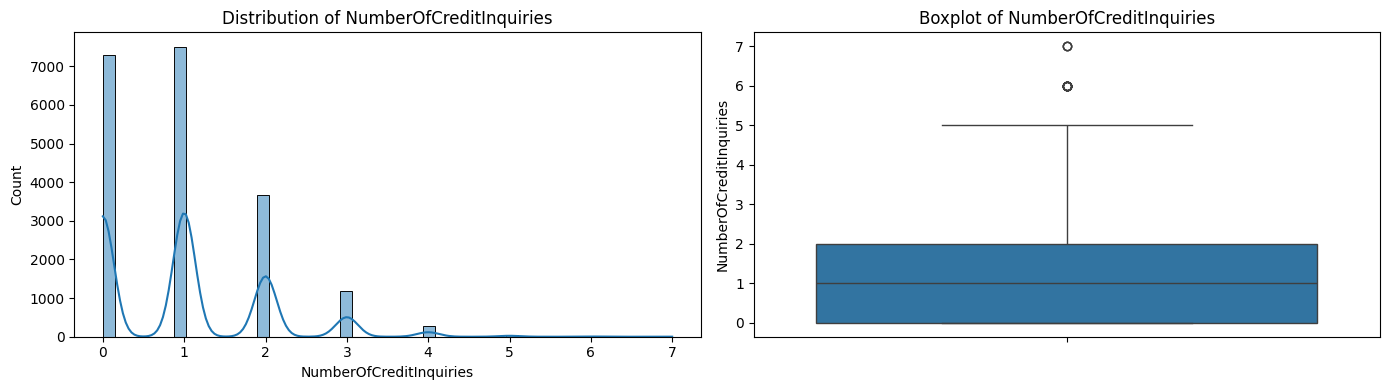

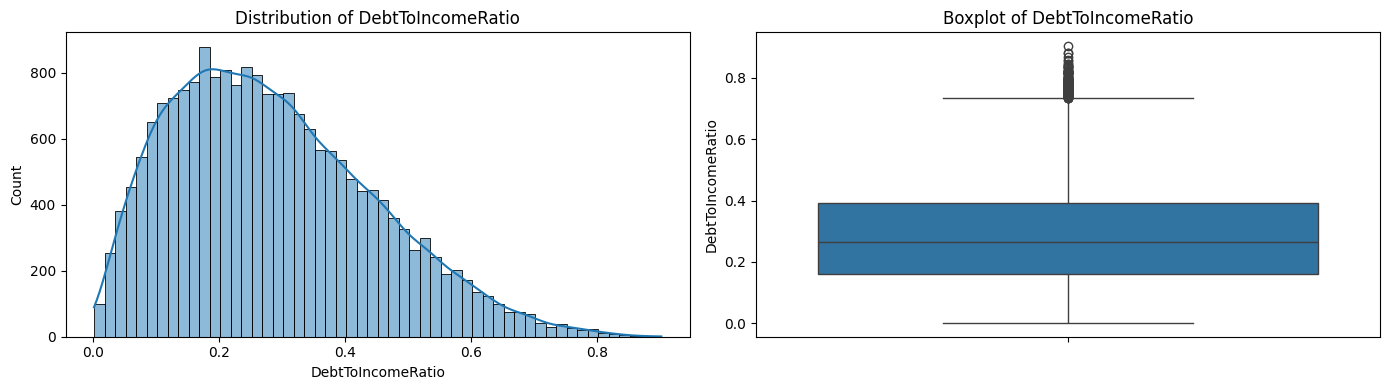

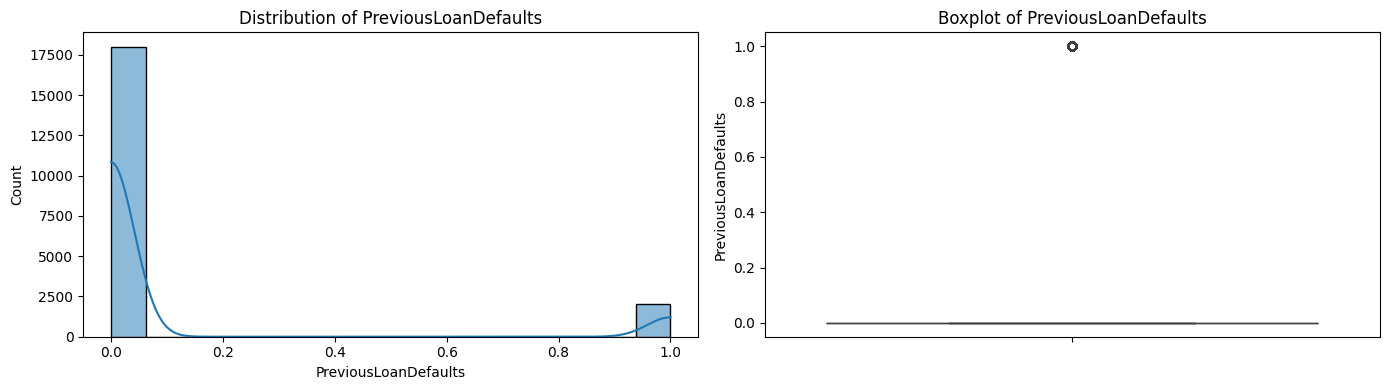

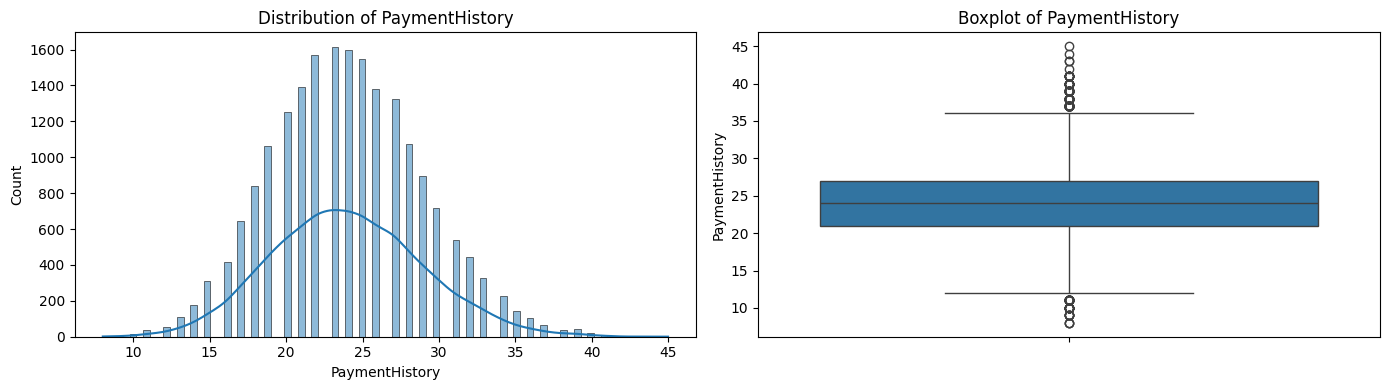

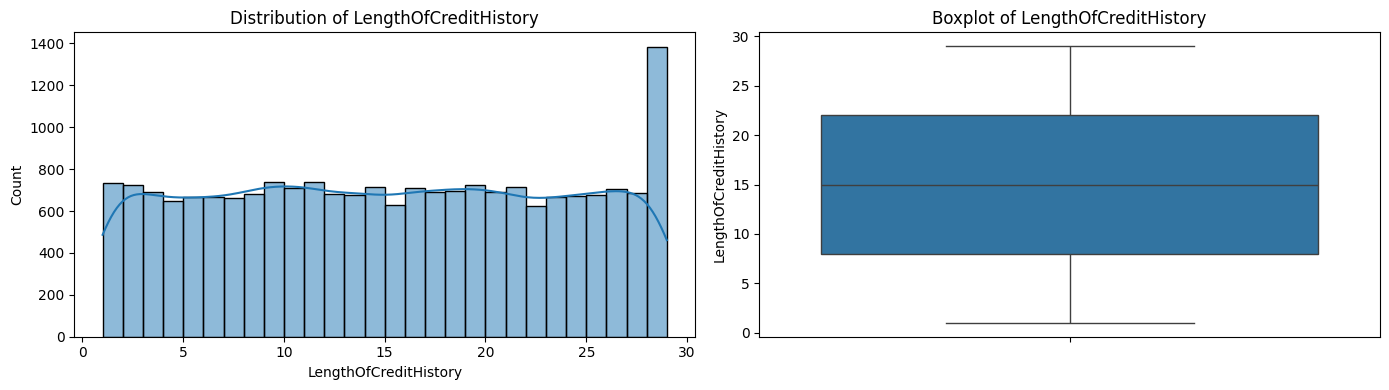

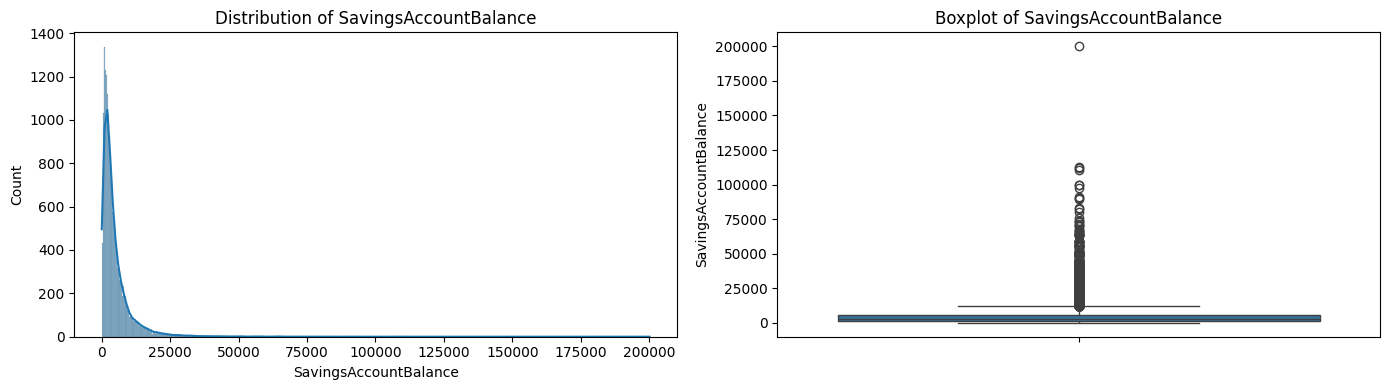

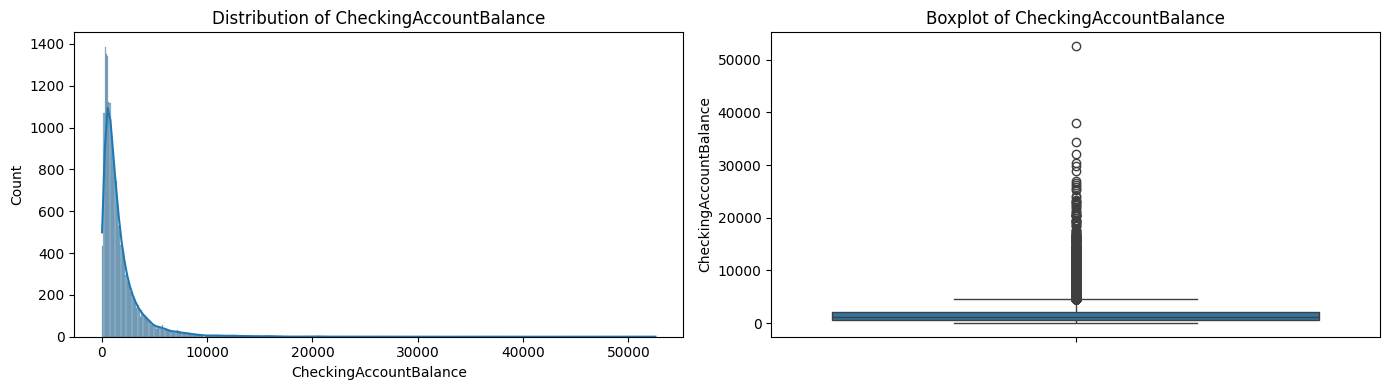

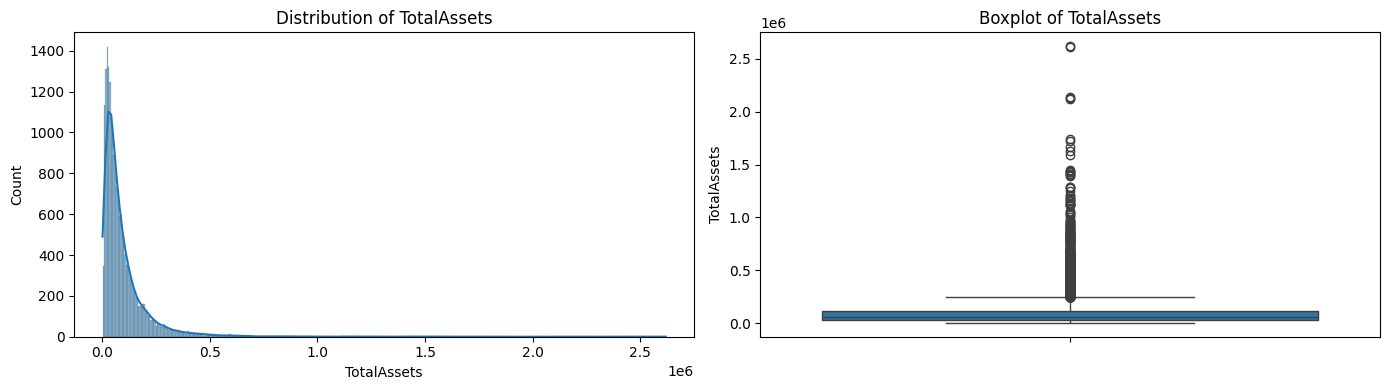

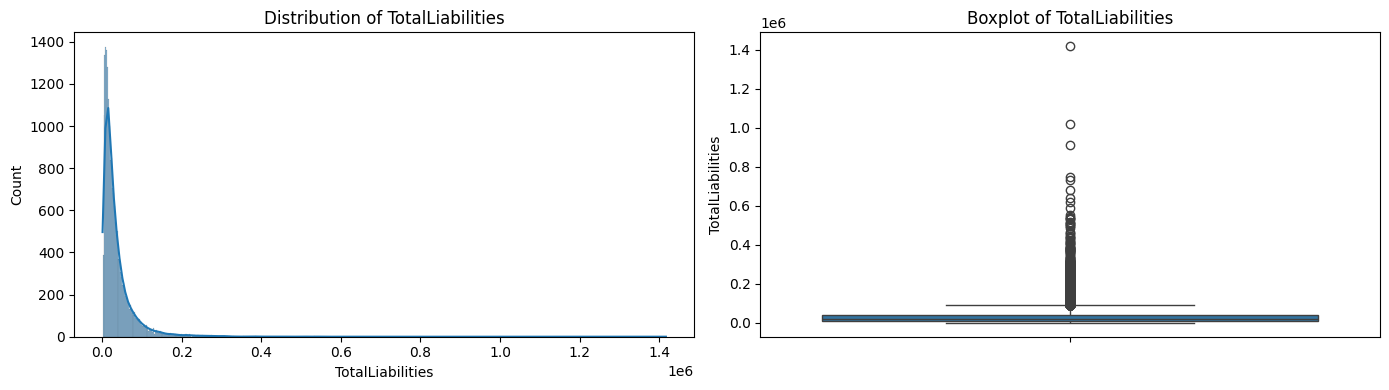

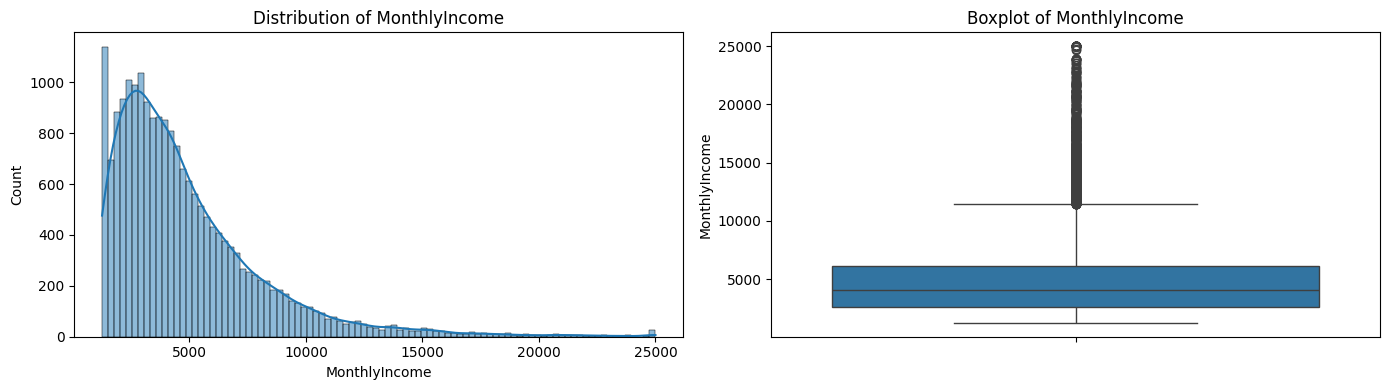

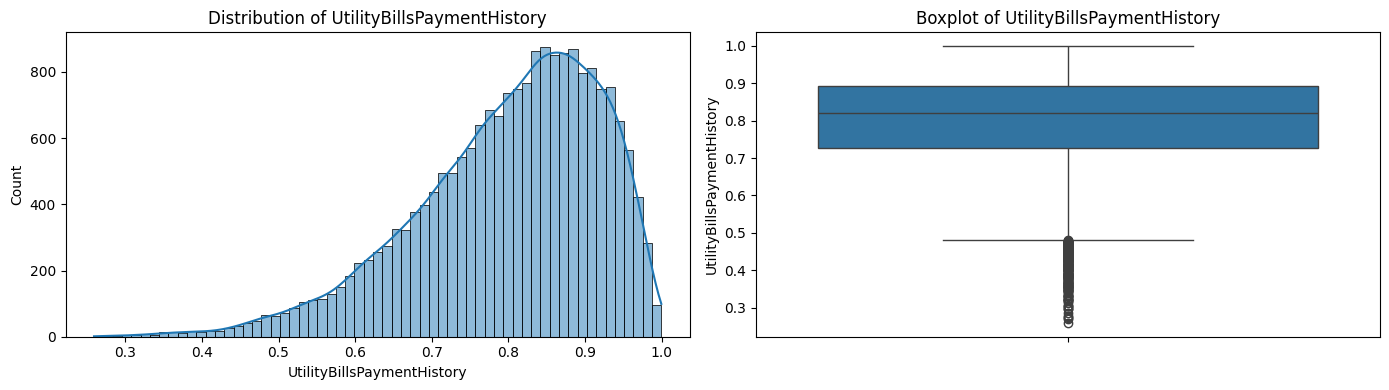

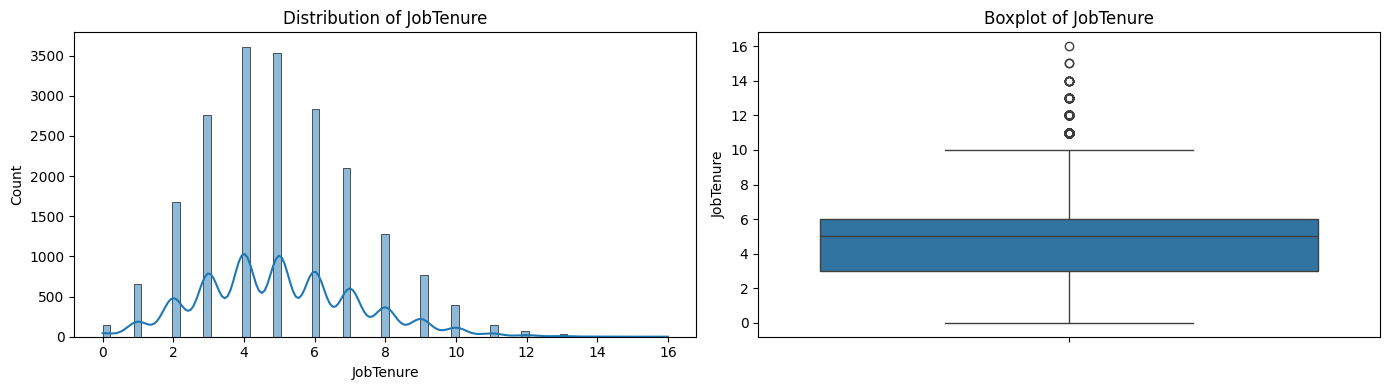

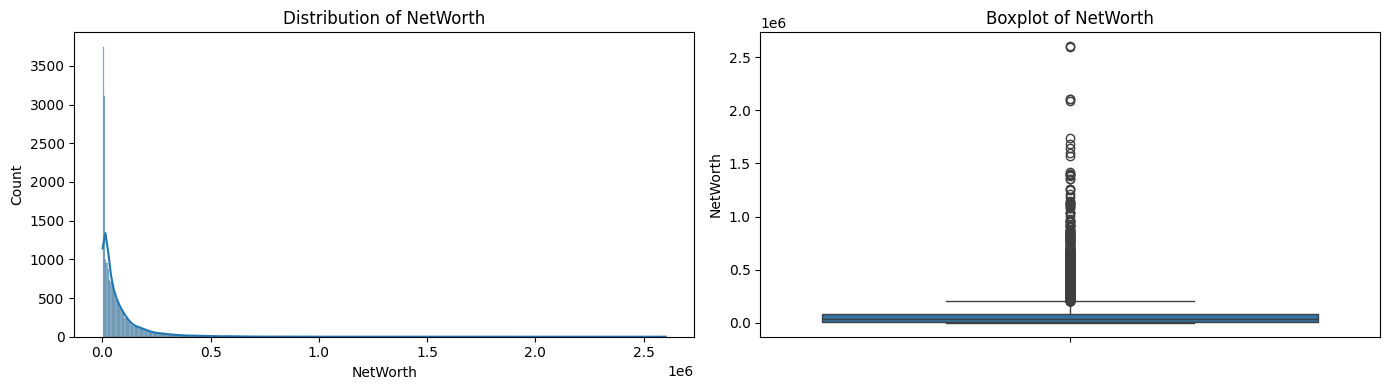

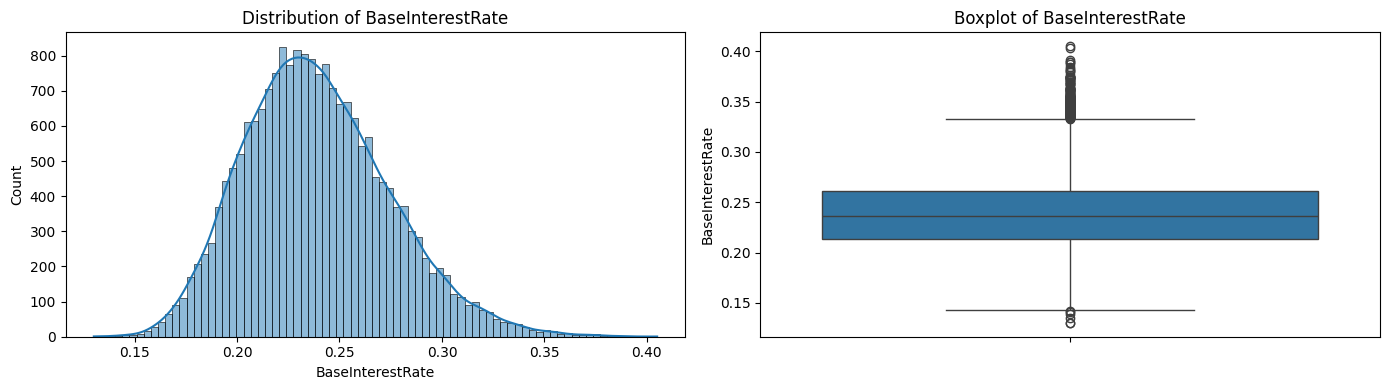

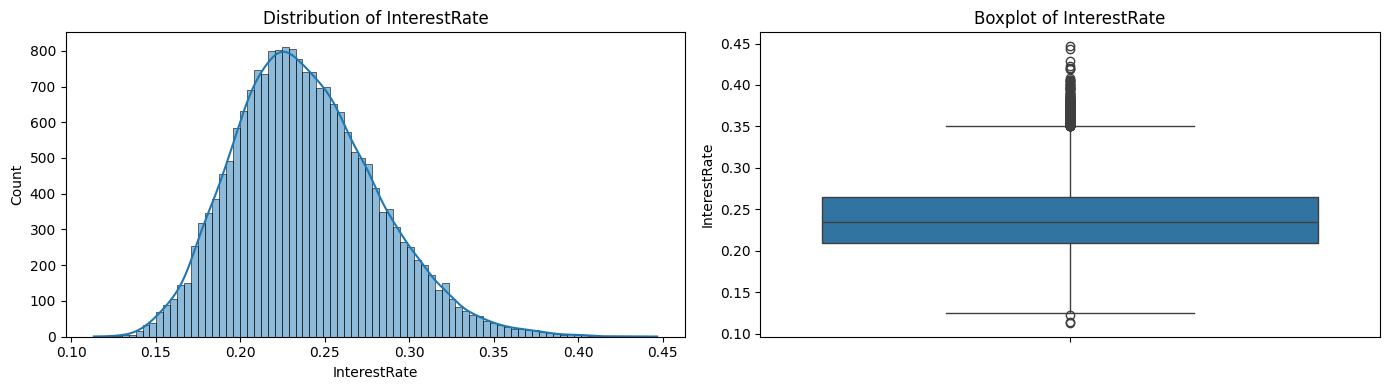

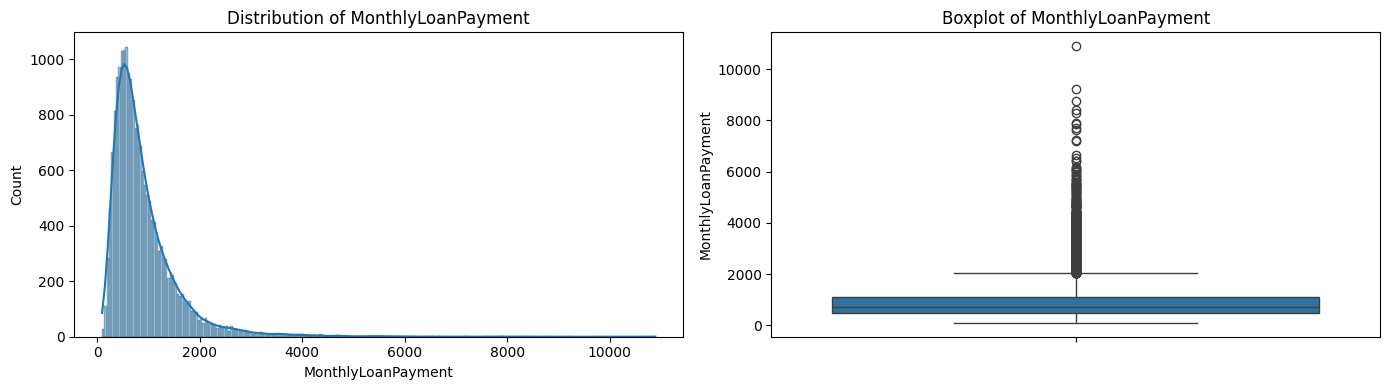

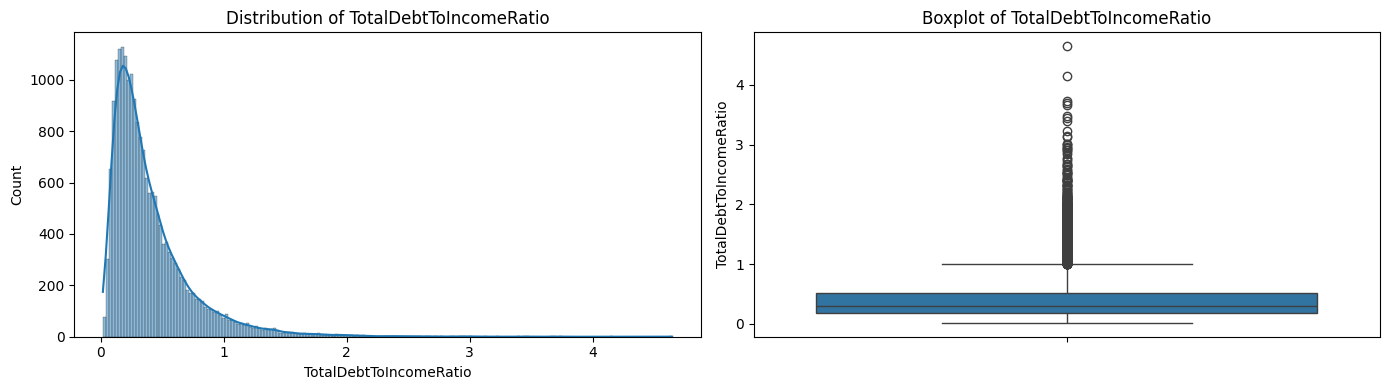

In [285]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude the target and risk score from distribution plots
plot_num_features = [f for f in numerical_features if f not in ['LoanApproved', 'RiskScore']]

for feature in plot_num_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[feature].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {feature}')
    sns.boxplot(y=df[feature].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {feature}')
    plt.tight_layout()
    plt.show()

#save the plots as images
fig.savefig(f'EDA charts\\Numerical_Feature_Distribution_Boxplot.png', dpi=300, bbox_inches='tight')

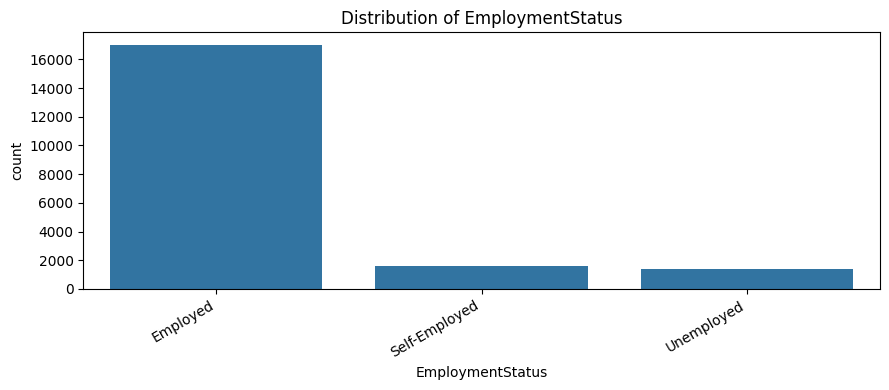

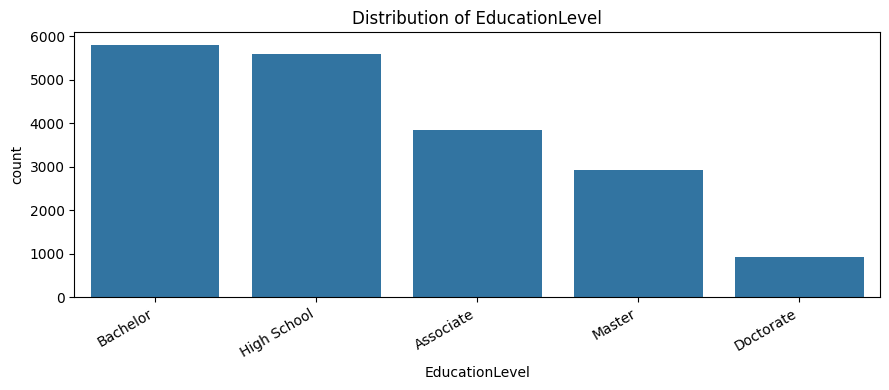

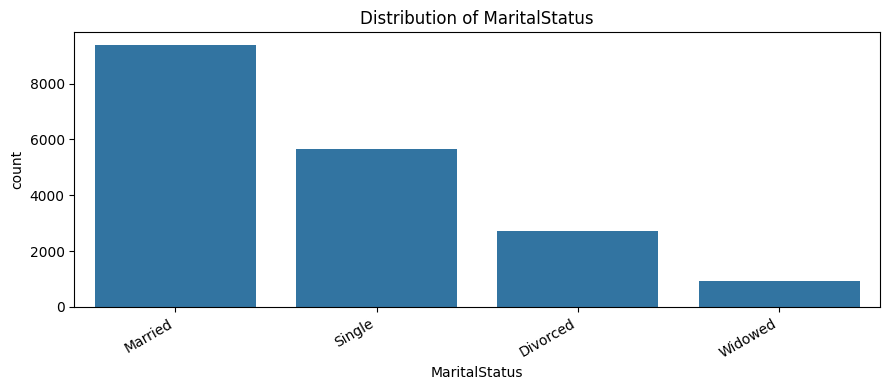

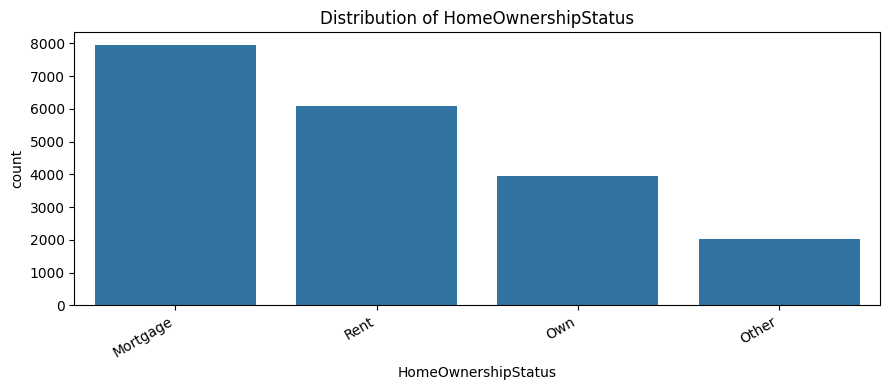

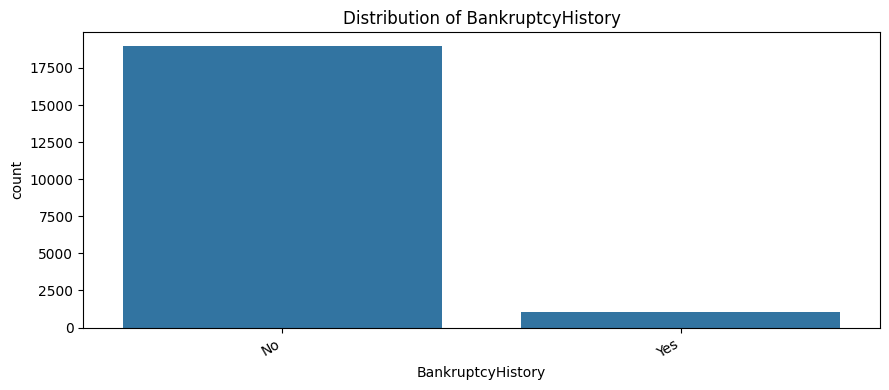

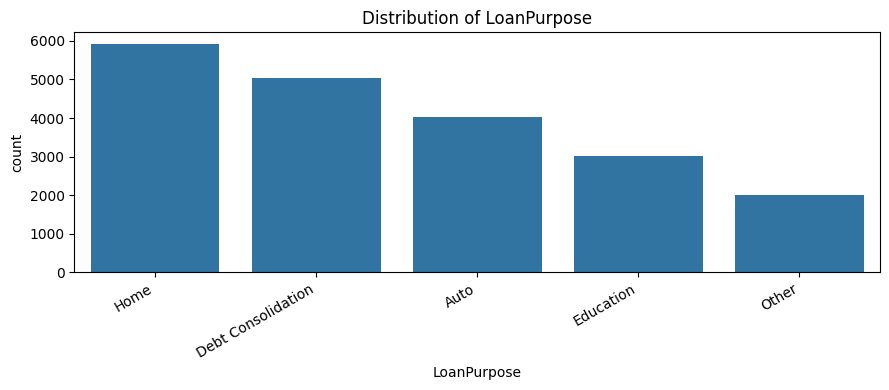

<Figure size 640x480 with 0 Axes>

In [286]:
categorical_features = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
                         'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

for feature in categorical_features:
    plt.figure(figsize=(9, 4))
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

#save the plots as images
plt.savefig(f'EDA charts\\Categorical_Feature_Distribution.png', dpi=300, bbox_inches='tight')

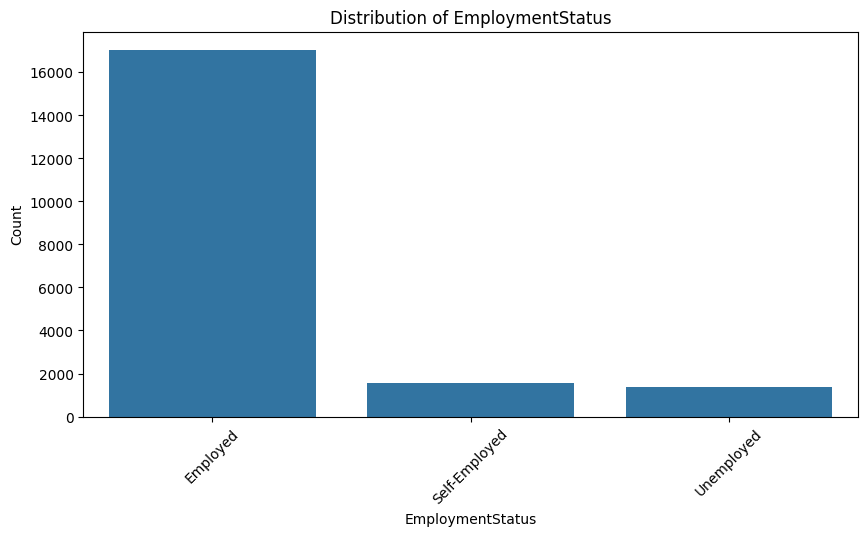

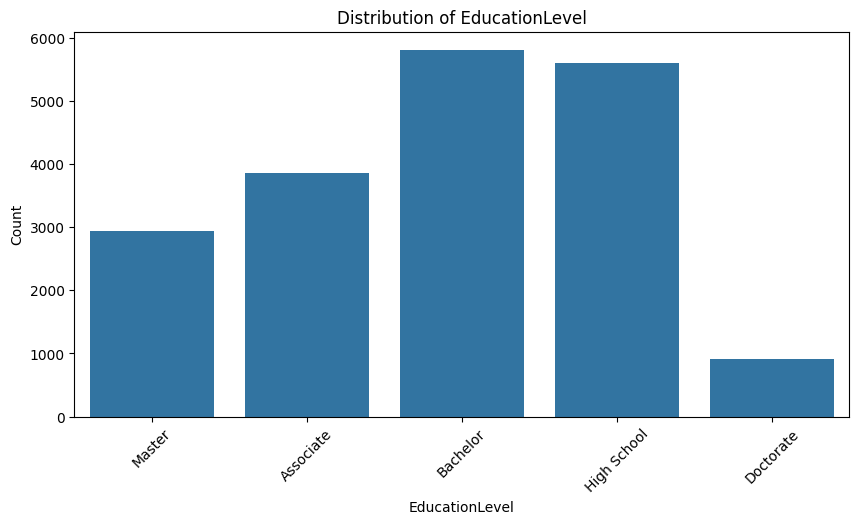

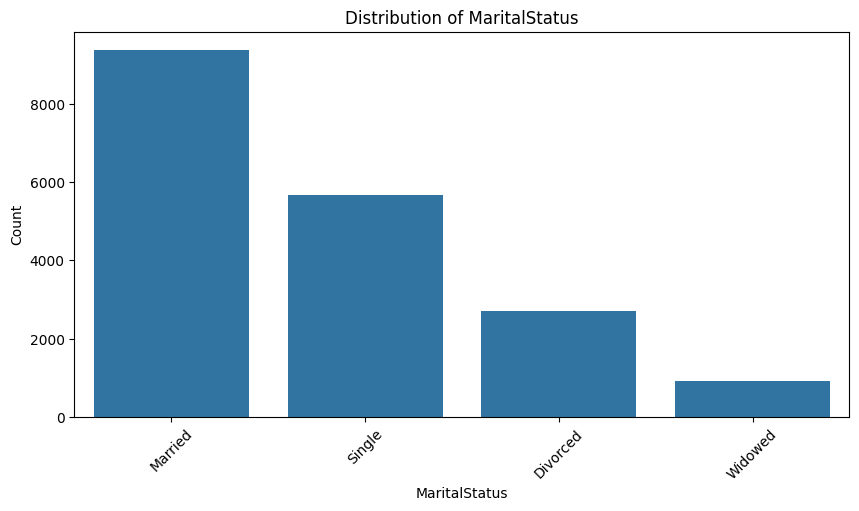

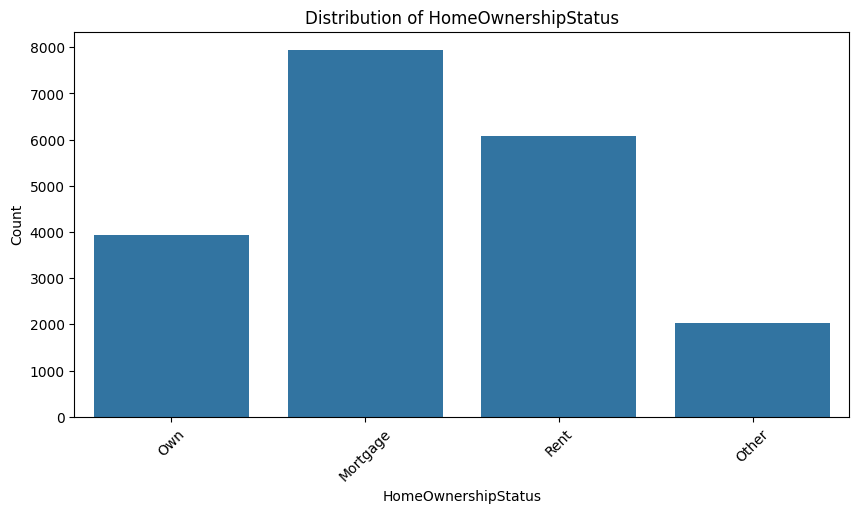

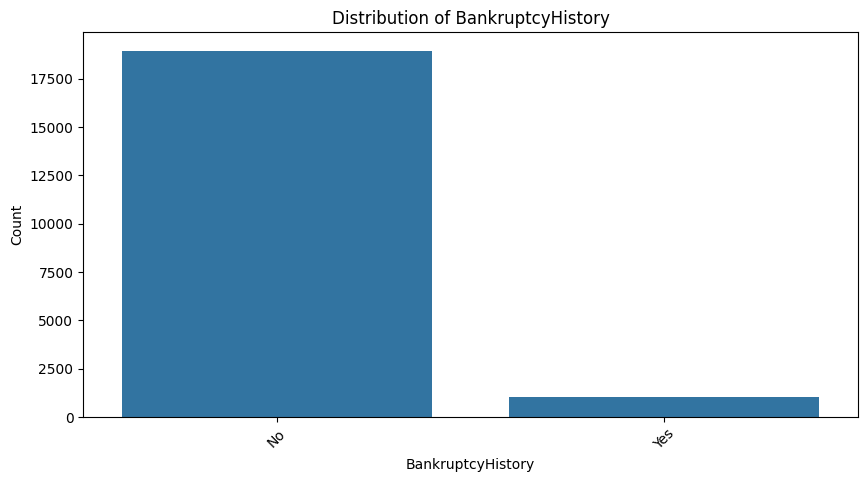

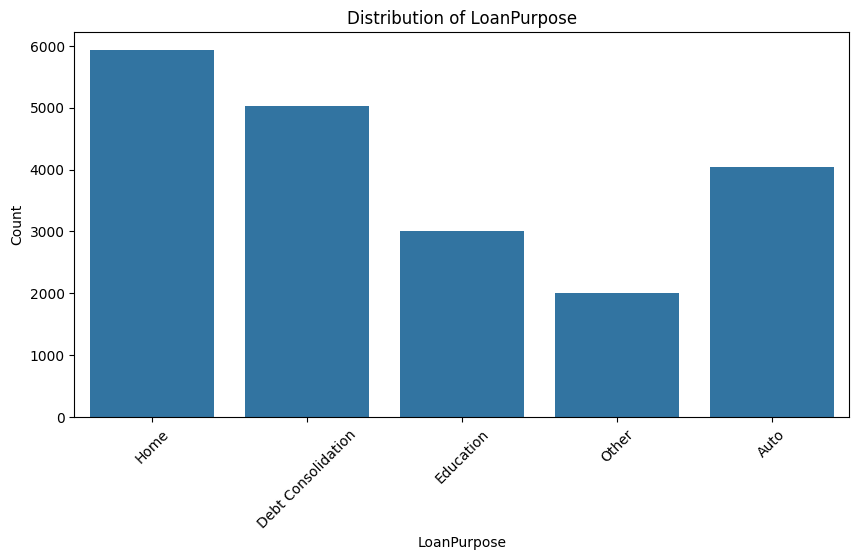

In [287]:
# Plot categorical distributions using count plots

for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(
        feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

**Observation**: 

Several financial variables — `AnnualIncome`, `LoanAmount`, `NetWorth`, and `SavingsAccountBalance` — are right-skewed with long tails and IQR-flagged outliers. These are expected in real lending data (genuine high earners and large loans) and will be retained. Categorical features show uneven class frequencies; for example, `BankruptcyHistory` is heavily skewed toward 'No', which is realistic but worth monitoring for model bias.


##### 3.10 Correlation Analysis

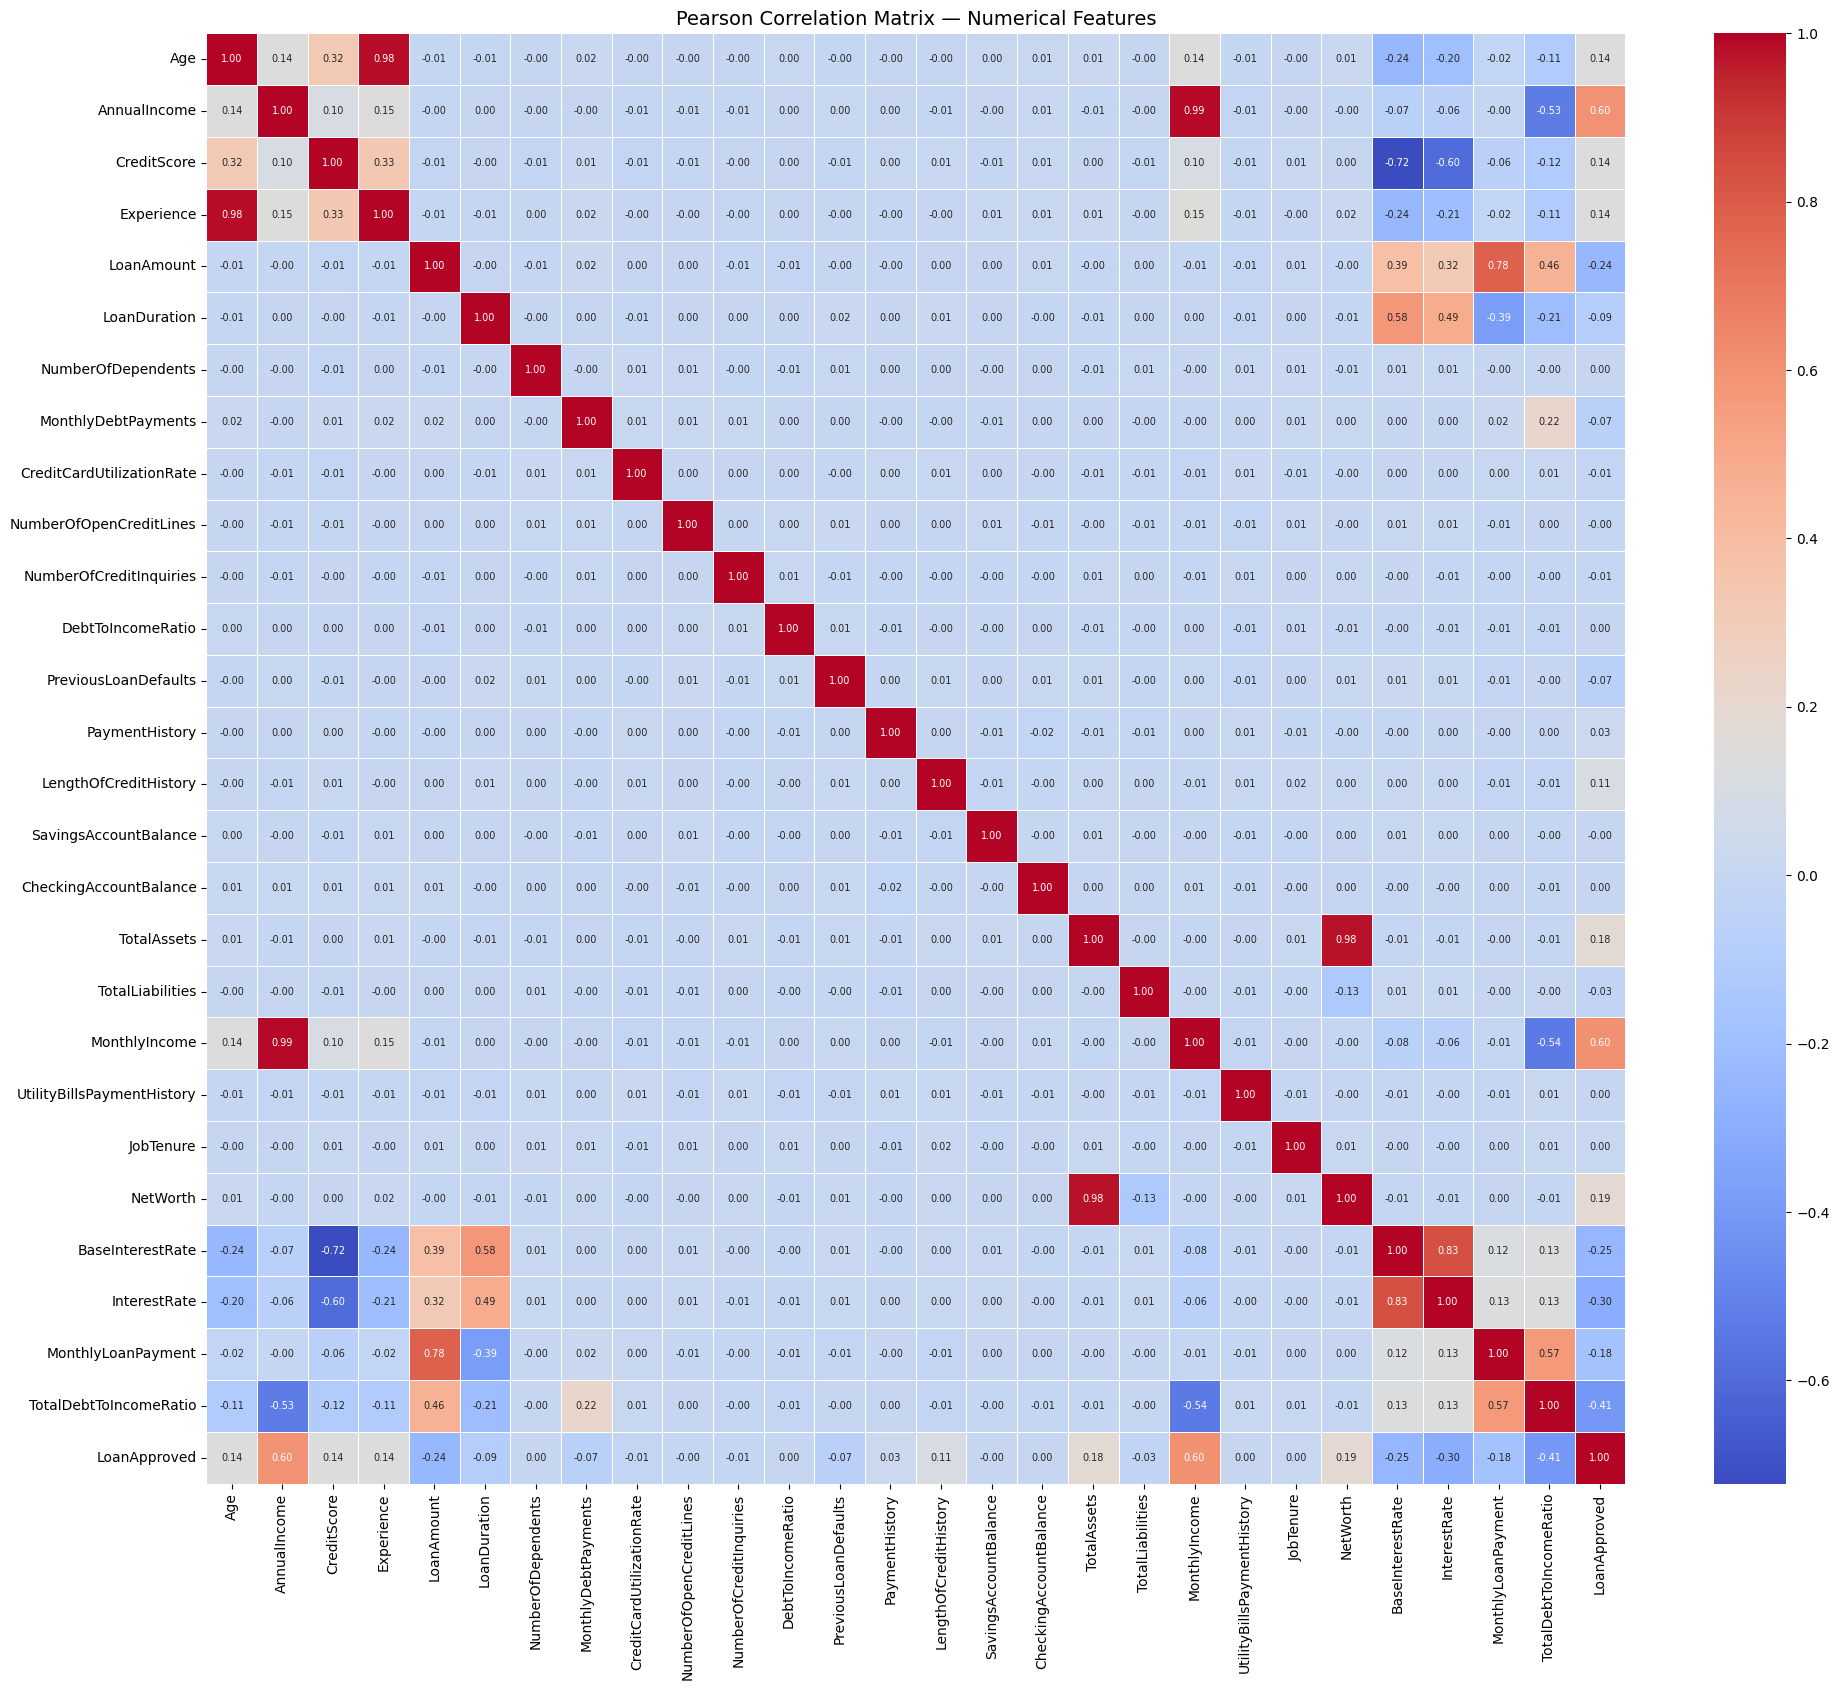

In [288]:
corr_features = [f for f in numerical_features if f not in ['RiskScore']]
correlation_matrix = df[corr_features].corr()

plt.figure(figsize=(20, 17))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, annot_kws={'size': 7})
plt.title('Pearson Correlation Matrix — Numerical Features', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#save the plot as an image
fig.savefig('EDA charts\\Correlation_Matrix.png', dpi=300, bbox_inches='tight')

**Observation:** 

Most numerical features have weak-to-moderate correlations with each other, limiting multicollinearity concerns. `AnnualIncome` and `MonthlyIncome` are strongly correlated (expected, as one is derived from the other). `BaseInterestRate` and `InterestRate` are also highly correlated — one could be dropped, but tree-based models handle this naturally. `TotalDebtToIncomeRatio` and `DebtToIncomeRatio` show moderate correlation with `LoanApproved`, indicating relevance as predictors. `RiskScore` was excluded because it is a post-decision variable that would cause target leakage.

##### 3.11 Relationship Analysis 

- Features Vs. Loan Approval

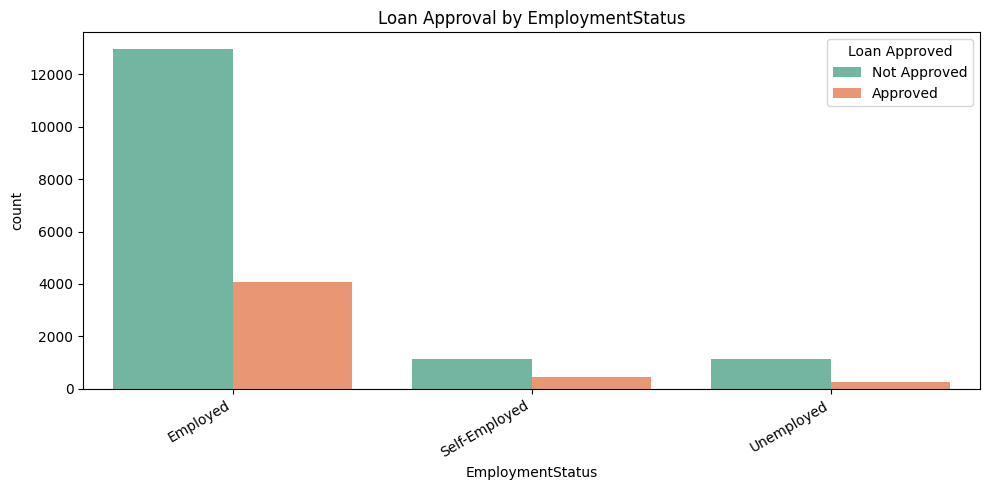

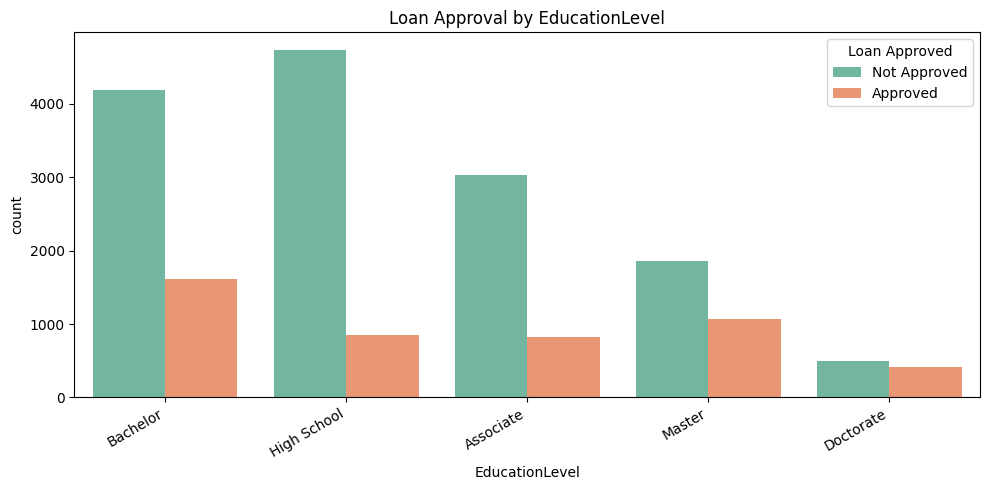

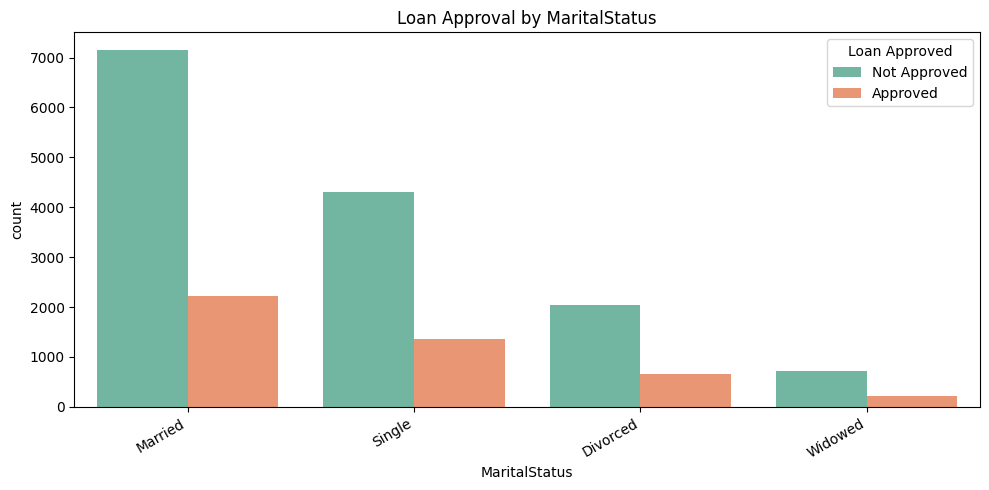

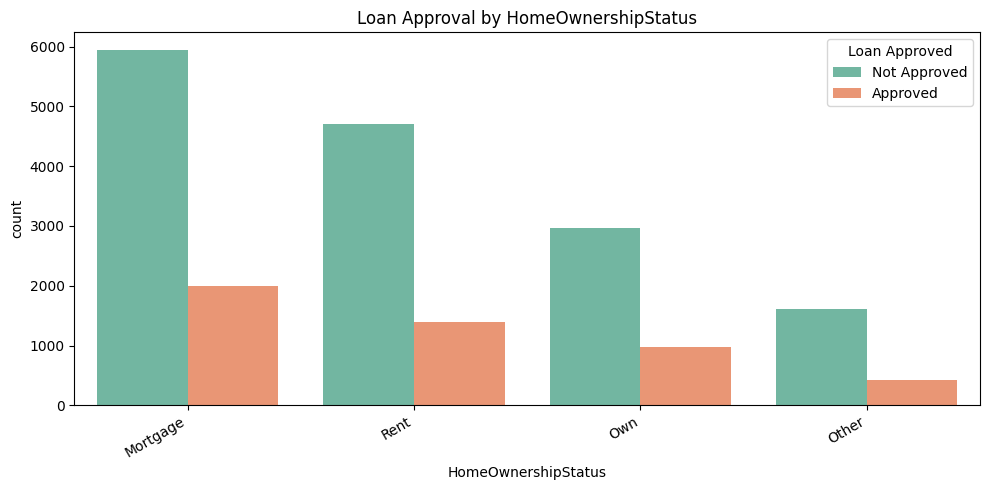

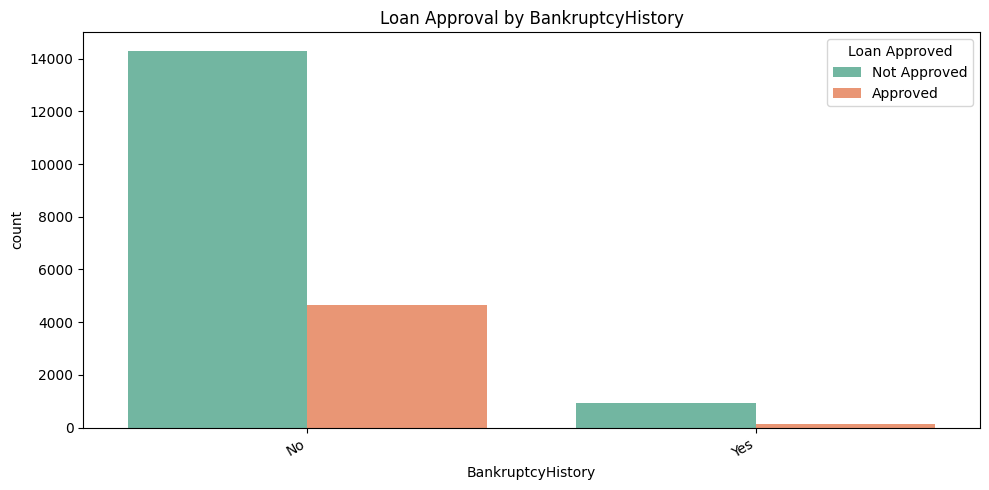

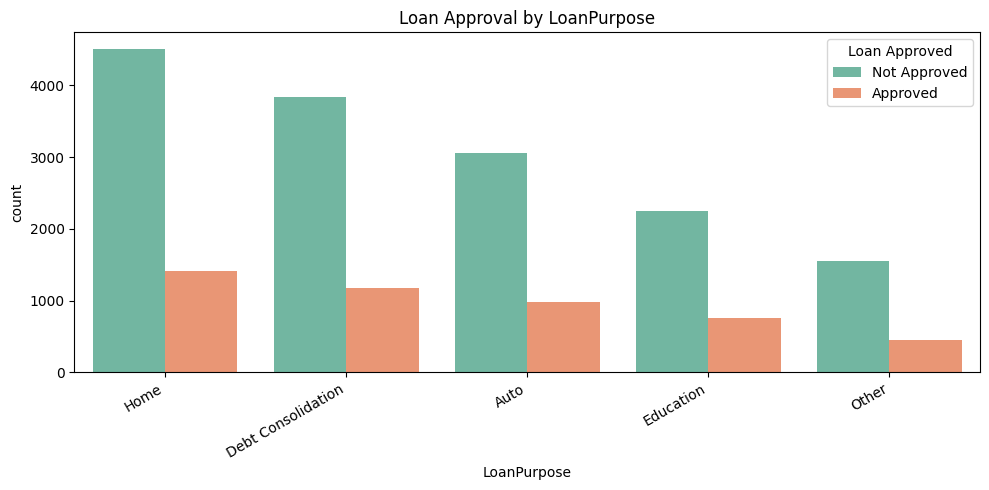

<Figure size 640x480 with 0 Axes>

In [289]:
# Plot categorical distributions using count plots
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature, hue='LoanApproved', palette='Set2',
                  order=df[feature].value_counts().index)
    plt.title(f'Loan Approval by {feature}')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
    plt.tight_layout()
    plt.show()

#save the plots as images
plt.savefig(f'EDA charts\\Loan_Approval_by_Categories.png', dpi=300, bbox_inches='tight')

- AnnualIncome Vs. Loan Amount

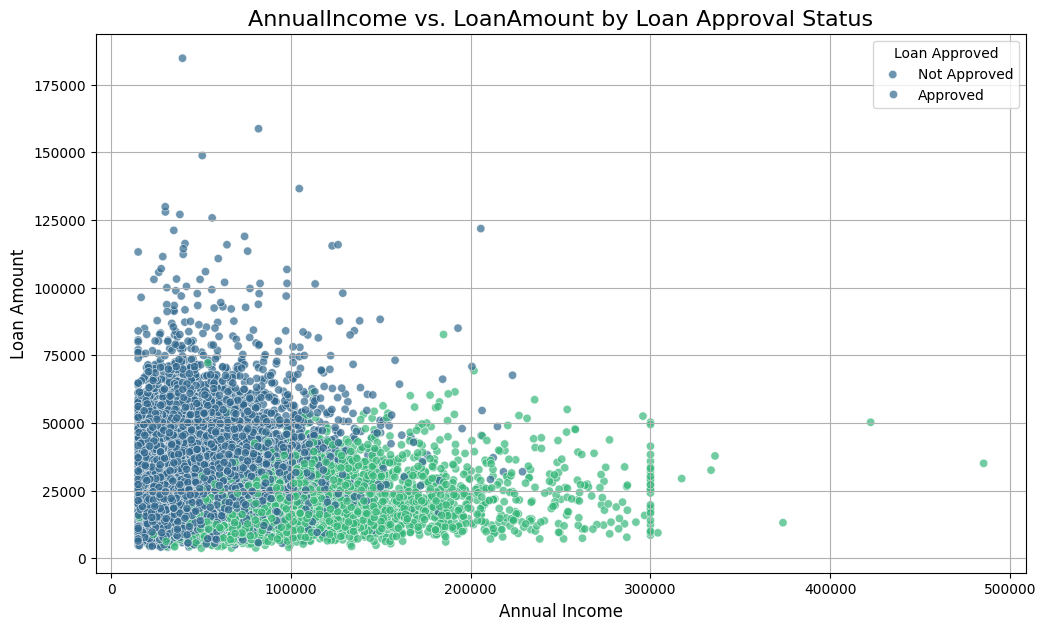

<Figure size 640x480 with 0 Axes>

In [290]:
# Visualize relationship between AnnualIncome and LoanAmount, colored by LoanApproved
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='AnnualIncome', y='LoanAmount', hue='LoanApproved', palette='viridis', alpha=0.7)
plt.title('AnnualIncome vs. LoanAmount by Loan Approval Status', fontsize=16)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
plt.grid(True)
plt.show()

#save the plot as an image
plt.savefig('EDA charts\\AnnualIncome_vs_LoanAmount.png', dpi=300, bbox_inches='tight')

- CreditScore Vs. LoanAmount

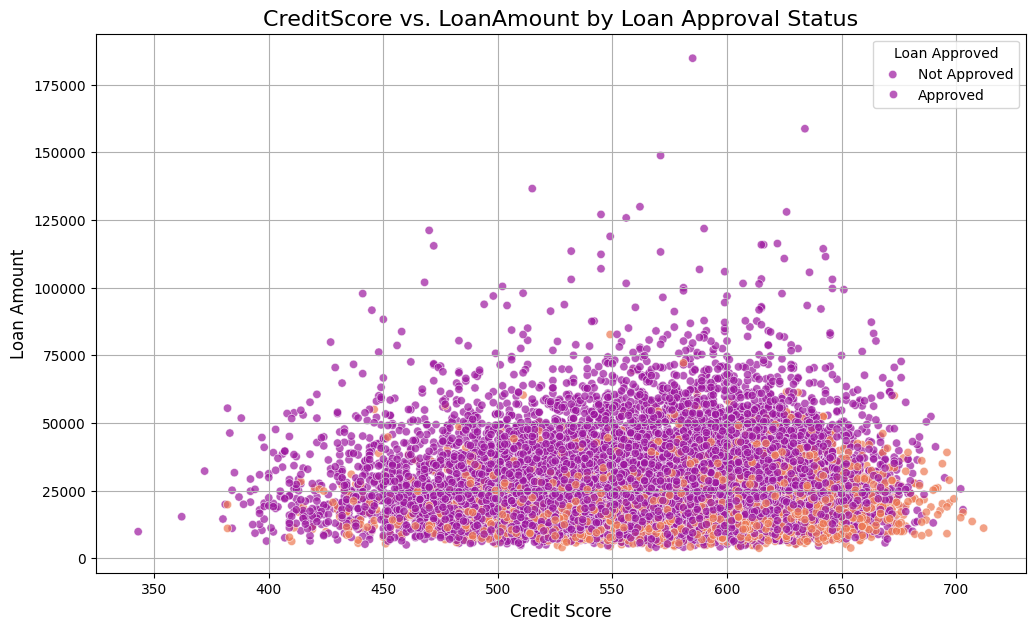

<Figure size 640x480 with 0 Axes>

In [291]:
# Visualize relationship between CreditScore and LoanAmount, colored by LoanApproved
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='CreditScore', y='LoanAmount', hue='LoanApproved', palette='plasma', alpha=0.7)
plt.title('CreditScore vs. LoanAmount by Loan Approval Status', fontsize=16)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Loan Approved', labels=['Not Approved', 'Approved'])
plt.grid(True)
plt.show()

#save the plot as an image
plt.savefig('EDA charts\\CreditScore_vs_LoanAmount.png', dpi=300, bbox_inches='tight')

**Observation:** 

Approved applicants tend to cluster at higher income and credit score levels, while large loan amounts relative to income are more common among rejections. `BankruptcyHistory` and `PreviousLoanDefaults` show clear stratification by approval outcome. These patterns confirm that the available features carry meaningful predictive signal.

##### 3.12 Data Quality Summary

In [292]:
# Display missing values - rank by missing count
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary['missing_count'] > 0]
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_percentage
MaritalStatus,1331,6.655
EducationLevel,901,4.505
SavingsAccountBalance,572,2.860


In [293]:
# Outlier detection via IQR
plot_num_features_nobin = [f for f in plot_num_features
                            if f not in ['PreviousLoanDefaults', 'BankruptcyHistory']]
outlier_summary = []
for col in plot_num_features_nobin:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    if n_out > 0:
        outlier_summary.append({'Feature': col, 'Outliers': n_out,
                                 'Lower Bound': round(lo, 2), 'Upper Bound': round(hi, 2)})
print(pd.DataFrame(outlier_summary).to_string(index=False))


                   Feature  Outliers  Lower Bound  Upper Bound
                       Age        64         8.00        72.00
              AnnualIncome       947    -32389.00    138459.00
               CreditScore       242       436.50       712.50
                Experience        75       -15.00        49.00
                LoanAmount       746     -7315.00     53725.00
       MonthlyDebtPayments       744      -131.00       981.00
 CreditCardUtilizationRate       130        -0.18         0.74
   NumberOfOpenCreditLines       249        -1.00         7.00
   NumberOfCreditInquiries        16        -3.00         5.00
         DebtToIncomeRatio       143        -0.18         0.73
            PaymentHistory       241        12.00        36.00
     SavingsAccountBalance      1547     -4948.88     12360.12
    CheckingAccountBalance      1522     -1811.50      4488.50
               TotalAssets      1442    -98157.25    246742.75
          TotalLiabilities      1533    -36727.88     9

Outliers are present in several financial features (`AnnualIncome`, `LoanAmount`, `SavingsAccountBalance`, `NetWorth`, etc.). These values are consistent with genuine borrower diversity and will be **retained** — Random Forest models are robust to extreme values. No duplicates exist. Missing values are limited to three columns and will be handled through imputation in the pipeline.

#### 4. Develop Feature Understanding:

##### 4.1 Feature Classification

The dataset contains a mix of numerical and categorical variables. Features were categorized based on their data types and expected modeling requirements.This classification informs the preprocessing pipeline design using scaling for numerical features and encoding for categorical variables.


In [294]:
# Explicit feature type lists
numerical_features = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration',
    'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio',
    'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
    'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
    'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
    'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'
]
ordinal_features = ['EducationLevel']   
nominal_features = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus',
                     'BankruptcyHistory', 'LoanPurpose']

print(f'Numerical  ({len(numerical_features)}): {numerical_features}')
print(f'Ordinal    ({len(ordinal_features)}): {ordinal_features}')
print(f'Nominal    ({len(nominal_features)}): {nominal_features}')
print(f'Target: LoanApproved  |  Excluded (leakage): RiskScore')


Numerical  (27): ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
Ordinal    (1): ['EducationLevel']
Nominal    (5): ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
Target: LoanApproved  |  Excluded (leakage): RiskScore


**Observation:** 

Features fall into three preprocessing groups. `EducationLevel` is treated as ordinal because degrees follow a natural academic hierarchy (High School → Associate → Bachelor → Master → Doctorate). All other categorical features are nominal. `RiskScore` is excluded — it is computed post-decision and would cause data leakage.


4.2 Identify features requiring special preprocessing

In [295]:
special_preprocessing = {
    'AnnualIncome'         : 'Was currency-formatted string — already cleaned to float. Right-skewed; scale before linear models.',
    'EducationLevel'       : 'Ordinal — encode with explicit category order. Contains ~4.5% missing values.',
    'MaritalStatus'        : 'Nominal — one-hot encode. Contains ~6.7% missing values.',
    'SavingsAccountBalance': 'Numeric — median impute ~2.9% missing values (likely indicates no savings account).',
    'BankruptcyHistory'    : 'Nominal binary (Yes/No) — one-hot encode with handle_unknown=ignore.',
    'InterestRate'         : 'Highly correlated with BaseInterestRate — tree models handle this; linear models may benefit from dropping one.',
    'MonthlyIncome'        : 'Derived directly from AnnualIncome — redundant but kept as tree models use feature importance to de-weight it.',
}
for feat, note in special_preprocessing.items():
    print(f'\n-  {feat}: {note}')


-  AnnualIncome: Was currency-formatted string — already cleaned to float. Right-skewed; scale before linear models.

-  EducationLevel: Ordinal — encode with explicit category order. Contains ~4.5% missing values.

-  MaritalStatus: Nominal — one-hot encode. Contains ~6.7% missing values.

-  SavingsAccountBalance: Numeric — median impute ~2.9% missing values (likely indicates no savings account).

-  BankruptcyHistory: Nominal binary (Yes/No) — one-hot encode with handle_unknown=ignore.

-  InterestRate: Highly correlated with BaseInterestRate — tree models handle this; linear models may benefit from dropping one.

-  MonthlyIncome: Derived directly from AnnualIncome — redundant but kept as tree models use feature importance to de-weight it.


4.3 Document missing value patterns and their potential meanings

                       Missing Count  Missing %  \
EducationLevel                   901       4.50   
MaritalStatus                   1331       6.65   
SavingsAccountBalance            572       2.86   

                                                     Likely Mechanism  
EducationLevel          MCAR — applicants likely declined to disclose  
MaritalStatus             MCAR — privacy preference or optional field  
SavingsAccountBalance  MNAR — missing likely means no savings account  


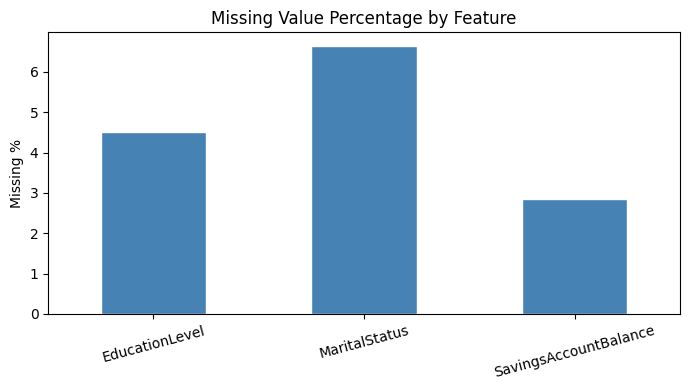

<Figure size 640x480 with 0 Axes>

In [296]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct,
                            'Likely Mechanism': [
                                'MCAR — applicants likely declined to disclose',
                                'MCAR — privacy preference or optional field',
                                'MNAR — missing likely means no savings account'
                            ]})
print(missing_df)

plt.figure(figsize=(7, 4))
missing_pct.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Missing Value Percentage by Feature')
plt.ylabel('Missing %')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#save the plot as an image
plt.savefig('EDA charts\\Missing_Values_Percentage.png', dpi=300, bbox_inches='tight')


**Observation:** 

All three missing-value columns are manageable (<7%). `EducationLevel` and `MaritalStatus` are likely Missing Completely At Random (MCAR) — the most frequent category will be used to impute. `SavingsAccountBalance` may be Missing Not At Random (MNAR), where absence signals no savings account — median imputation will be applied to preserve the distribution.


4.4 Note Potential Feature Engineering Opportunities

In [297]:
opportunities = [
    '1. IncomeToLoanRatio = AnnualIncome / LoanAmount — affordability signal',
    '2. LoanToAssetRatio  = LoanAmount / TotalAssets  — risk relative to borrower assets',
    '3. NetWorthToLoanRatio = NetWorth / LoanAmount   — financial cushion indicator',
    '4. Binary flag: SavingsAccountBalance == 0       — no-savings risk signal',
    '5. InterestSpread = InterestRate - BaseInterestRate — pricing premium signal',
    '6. Log transform of AnnualIncome, LoanAmount, NetWorth to reduce skew for linear models',
]
print('Potential feature engineering opportunities:')
for o in opportunities:
    print(f'  {o}')

# NOTE: These are not implemented in the base pipeline to keep it clean and interpretable,
# but they represent high-priority improvements for a future iteration.


Potential feature engineering opportunities:
  1. IncomeToLoanRatio = AnnualIncome / LoanAmount — affordability signal
  2. LoanToAssetRatio  = LoanAmount / TotalAssets  — risk relative to borrower assets
  3. NetWorthToLoanRatio = NetWorth / LoanAmount   — financial cushion indicator
  4. Binary flag: SavingsAccountBalance == 0       — no-savings risk signal
  5. InterestSpread = InterestRate - BaseInterestRate — pricing premium signal
  6. Log transform of AnnualIncome, LoanAmount, NetWorth to reduce skew for linear models


The following high-priority features and transformations represent key improvements for future model iterations to capture deeper risk signals:

- IncomeToLoanRatio: AnnualIncome / LoanAmount serves as an affordability signal.

- LoanToAssetRatio: LoanAmount / TotalAssets measures risk relative to borrower assets.

- NetWorthToLoanRatio: NetWorth / LoanAmount acts as a financial cushion indicator.

- No-Savings Flag: Binary flag where SavingsAccountBalance == 0 signals risk.

- InterestSpread: InterestRate - BaseInterestRate captures the pricing premium signal.

- Log Transformations: Applied to AnnualIncome, LoanAmount, and NetWorth to reduce skew for linear models.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



### 5.1–5.2 Preprocessing Pipeline Design

Three parallel sub-pipelines are constructed and combined in a `ColumnTransformer`:
- **Numerical pipeline:** median imputation → StandardScaler
- **Ordinal pipeline:** most-frequent imputation → OrdinalEncoder (explicit category order)
- **Nominal pipeline:** most-frequent imputation → OneHotEncoder

##### Flow A: Numerical Sub-Pipeline
  REASONING: Median imputation is robust to outliers. StandardScaler is required for Logistic Regression (assumes mean = 0, unit-variance inputs).

In [298]:
#Numerical features requiring scaling (linear models)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

##### Flow B: Ordinal Categorical Sub-Pipeline
  REASONING: EducationLevel has a strict natural hierarchy. OrdinalEncoder with an explicit category order ensures mathematical intervals reflect educational progression.

In [299]:
education_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=education_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

#### Flow C: Nominal Categorical Sub-Pipeline ---
 REASONING: Nominal features have no ranking. OneHotEncoder creates orthogonal binary features, allowing each category to be weighted independently by the model.


In [300]:
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [301]:
#ColumnTransformer: Orchestrate parallel flows
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
])
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'AnnualIncome', 'CreditScore',
                                  'Experience', 'LoanAmount', 'LoanDuration',
                                  'NumberOfDependents', 'MonthlyDebtPayments',
                                  'CreditCardUtilizationRate',
                                  'NumberOfOpenCreditLines',
                                  'NumberOfCreditInquiries',
                                  'DebtToIncomeRatio',...
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'Doct

**Preprocessing Design Summary:**
- Separate pipeline flows for numerical, ordinal, and nominal data prevent data corruption across feature types.
- `ColumnTransformer` applies all transformations in parallel and passes the combined feature matrix to the classifier.
- Imputation is performed **inside** the pipeline, eliminating any risk of data leakage from the test set.
- StandardScaler is applied to all numerical features, satisfying Logistic Regression's variance assumptions.

A `FeatureUnion` = (splitting `SavingsAccountBalance` into a continuous scaled value and a binary existence flag) was considered and is noted as a future enhancement. The chosen design keeps the pipeline straightforward and avoids dimension mismatch errors with downstream grid search parameter keys.


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”



### 6. Modeling Approach
#### 6.1 Train-Test Split and Feature Separation


In [302]:
#  Modeling Code Here - Create New Cells as Needed

# Define features and target
target = 'LoanApproved'
features_drop = ['LoanApproved', 'RiskScore']

X = df.drop(columns=features_drop)
y = df[target]

#80/20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')


Training set:  16000 rows
Test set:      4000 rows
Train class balance: {0: 12176, 1: 3824}
Test class balance:  {0: 3044, 1: 956}


#### 6.2 Model Algorithm Selection

Four algorithms are implemented to allow a meaningful comparison:

1. Logistic Regression — linear baseline; interpretable, fast, good for regulatory explainability.

2. Decision Tree — non-linear, highly interpretable single tree; often under-performs ensembles.

3. Random Forest — ensemble of decorrelated trees; robust to noise and outliers, handles feature interactions well.

4. Gradient Boosting — sequential ensemble; often achieves highest predictive accuracy at the cost of interpretability.

In [303]:
# Build complete pipelines for all four models
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])

pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced', max_depth=10, random_state=42
    ))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42
    ))
])

pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ))
])


#### 6.3 Cross-Validation Comparison

REASONING: Imbalanced classes make accuracy misleading. `StratifiedKFold` with 5 folds ensures each fold maintains the same class ratio. ROC-AUC and F1 (weighted) are used to track ranking performance and class-level precision-recall balance.


5-Fold Stratified Cross-Validation Results:
                     CV AUC (mean)  CV AUC (std)  CV F1 (mean)  CV F1 (std)
Logistic Regression         0.9946        0.0009        0.9577       0.0029
Decision Tree               0.8904        0.0163        0.8911       0.0082
Random Forest               0.9767        0.0032        0.9249       0.0078
Gradient Boosting           0.9852        0.0021        0.9407       0.0048


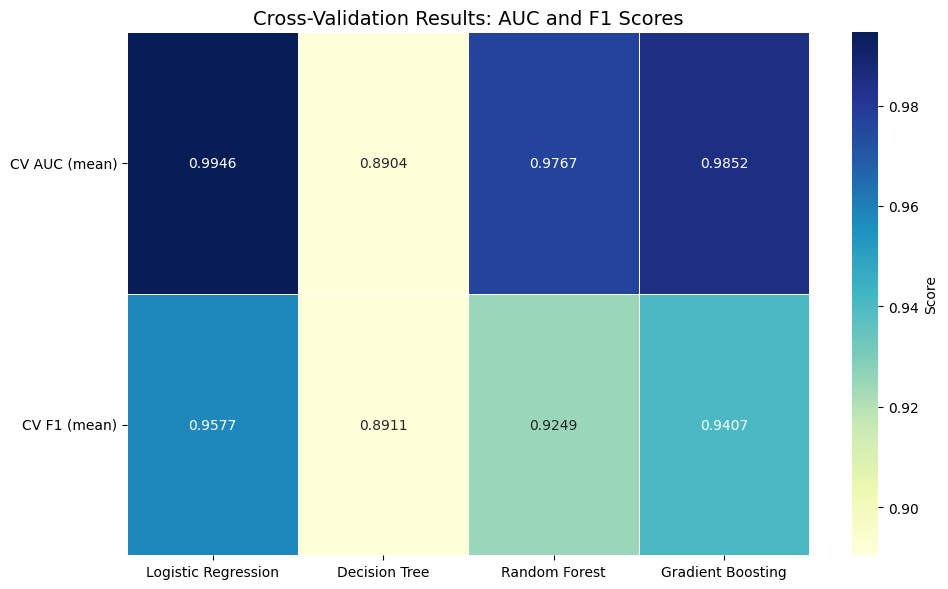

<Figure size 640x480 with 0 Axes>

In [304]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_pipelines = {
    'Logistic Regression' : pipeline_lr,
    'Decision Tree'       : pipeline_dt,
    'Random Forest'       : pipeline_rf,
    'Gradient Boosting'   : pipeline_gb,
}

cv_results = {}
for name, pipe in model_pipelines.items():
    res = cross_validate(pipe, X_train, y_train,
                         cv=cv_strategy,
                         scoring=['roc_auc', 'f1_weighted'],
                         n_jobs=-1)
    cv_results[name] = {
        'CV AUC (mean)' : res['test_roc_auc'].mean(),
        'CV AUC (std)'  : res['test_roc_auc'].std(),
        'CV F1 (mean)'  : res['test_f1_weighted'].mean(),
        'CV F1 (std)'   : res['test_f1_weighted'].std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
print('5-Fold Stratified Cross-Validation Results:')
print(cv_df.to_string())

#save the cross-validation results as an image
plt.figure(figsize=(10, 6))
sns.heatmap(cv_df[['CV AUC (mean)', 'CV F1 (mean)']].T, annot=True, fmt='.4f', cmap='YlGnBu',
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.title('Cross-Validation Results: AUC and F1 Scores', fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.savefig('Model Evaluation Charts\\Cross_Validation_Results.png', dpi=300, bbox_inches='tight')


**Observation:** 

Logistic Regression achieves the highest CV ROC-AUC (≈0.9946), indicating that well-scaled linear combinations of these financial features are highly discriminative. Random Forest (≈0.9767) and Gradient Boosting (≈0.9852) also perform strongly. Decision Tree performs lowest (≈0.8904), confirming that a single tree underfits the problem complexity. All models except Decision Tree comfortably exceed the 0.90 baseline target.


#### **Hyperparameter Tuning and Optimisation**

#### 7.1 Parameter Grid Definition

REASONING: Grid search is run on Random Forest and Logistic Regression — the two strongest interpretable candidates. Parameters are chosen based on known algorithmic behaviour:

- `n_estimators`: more trees → lower variance, diminishing returns above 200.
- `max_depth`: controls overfitting; `None` allows full growth.
- `min_samples_split`: minimum node size to split — larger values regularise against overfitting.
- `C` (LR): inverse regularisation strength — smaller `C` = stronger regularisation.


In [305]:
#Random Forest hyperparameter
param_grid_rf = {
    'classifier__n_estimators'    : [100, 200],
    'classifier__max_depth'       : [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

#Logistic Regression hyperparameter
param_grid_lr = {
    'classifier__C'       : [0.01, 0.1, 1, 10],
    'classifier__solver'  : ['lbfgs', 'saga']
}


#### 7.2 GridSearchCV with Cross-Validation


In [306]:
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#Random Forest Grid Search
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=cv_tune,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
grid_search_rf.fit(X_train, y_train)
print(f'Best RF Parameters:  {grid_search_rf.best_params_}')
print(f'Best RF CV AUC:      {grid_search_rf.best_score_:.4f}')


Best RF Parameters:  {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best RF CV AUC:      0.9767


In [307]:
#Logistic Regression Grid Search
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv_tune,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
grid_search_lr.fit(X_train, y_train)
print(f'Best LR Parameters:  {grid_search_lr.best_params_}')
print(f'Best LR CV AUC:      {grid_search_lr.best_score_:.4f}')


Best LR Parameters:  {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Best LR CV AUC:      0.9946


In [326]:
#Saving best model for random forest
best_rf = grid_search_rf.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

#jsave the model
joblib.dump(best_rf, 'Models\\best_random_forest_model.pkl')

#Saving best model for logistic regression
best_lr = grid_search_lr.best_estimator_
best_lr.fit(X_train, y_train)
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

#save the model
joblib.dump(best_lr, 'Models\\best_logistic_regression_model.pkl')

print('Models saved successfully!')

Models saved successfully!


#### 7.3 Parameter Combination Impact and Trade-offs


In [308]:
# Random Forest trade-off analysis
cv_rf_df = pd.DataFrame(grid_search_rf.cv_results_)[[
    'param_classifier__n_estimators',
    'param_classifier__max_depth',
    'param_classifier__min_samples_split',
    'mean_test_score', 'mean_train_score', 'mean_fit_time'
]].sort_values('mean_test_score', ascending=False).head(6)

print('Top Random Forest Parameter Configurations:')
print(cv_rf_df.round(4).to_string(index=False))


Top Random Forest Parameter Configurations:
 param_classifier__n_estimators param_classifier__max_depth  param_classifier__min_samples_split  mean_test_score  mean_train_score  mean_fit_time
                            200                          20                                    2           0.9767               1.0        22.3102
                            200                        None                                    5           0.9766               1.0        16.3803
                            200                        None                                    2           0.9766               1.0        21.1299
                            200                          20                                    5           0.9765               1.0        22.1117
                            100                          20                                    2           0.9759               1.0        10.7558
                            100                        None               

In [309]:
# Logistic Regression trade-off analysis
cv_lr_df = pd.DataFrame(grid_search_lr.cv_results_)[[
    'param_classifier__C',
    'param_classifier__solver',
    'mean_test_score', 'mean_train_score', 'mean_fit_time'
]].sort_values('mean_test_score', ascending=False).head(6)

print('Top Logistic Regression Parameter Configurations:')
print(cv_lr_df.round(4).to_string(index=False))


Top Logistic Regression Parameter Configurations:
 param_classifier__C param_classifier__solver  mean_test_score  mean_train_score  mean_fit_time
                10.0                    lbfgs           0.9946            0.9951         0.3010
                10.0                     saga           0.9946            0.9951        18.5601
                 1.0                    lbfgs           0.9945            0.9950         0.4859
                 1.0                     saga           0.9945            0.9950        21.6624
                 0.1                    lbfgs           0.9937            0.9942         0.3776
                 0.1                     saga           0.9937            0.9942        12.7729


**Optimization Summary:**

**Random Forest:** 
Best configuration uses `n_estimators=200`, `max_depth=20`, `min_samples_split=5`. Deeper trees marginally improve AUC but increase fit time. Limiting `min_samples_split` to 5 reduces overfitting.

**Logistic Regression:** 
Regularisation (`C`) has relatively minor impact because the data is well-behaved and linearly separable after scaling. Higher `C` values (less regularisation) perform slightly better, suggesting the linear decision boundary is not overfitting.

**Trade-off note:** 
LR trains orders of magnitude faster than RF. For real-time inference at scale, LR's near-equivalent AUC with far lower compute cost makes it a strong production candidate.


Saving Model Files

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

#### 8.1 Final Test Set Evaluation

In [310]:
# Evaluate both optimised models on the held-out test set

#Random Forest best model
best_rf = grid_search_rf.best_estimator_

y_pred_rf   = best_rf.predict(X_test)
y_proba_rf  = best_rf.predict_proba(X_test)[:, 1]

print('Random Forest — Test Set Performance:')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Not Approved', 'Approved']))



Random Forest — Test Set Performance:
ROC-AUC: 0.9791
              precision    recall  f1-score   support

Not Approved       0.94      0.97      0.96      3044
    Approved       0.90      0.80      0.85       956

    accuracy                           0.93      4000
   macro avg       0.92      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



In [311]:
#Logistic Regression best model
best_lr = grid_search_lr.best_estimator_

y_pred_lr   = best_lr.predict(X_test)
y_proba_lr  = best_lr.predict_proba(X_test)[:, 1]


print('\nLogistic Regression — Test Set Performance:')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Not Approved', 'Approved']))


Logistic Regression — Test Set Performance:
ROC-AUC: 0.9945
              precision    recall  f1-score   support

Not Approved       0.99      0.96      0.97      3044
    Approved       0.88      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000



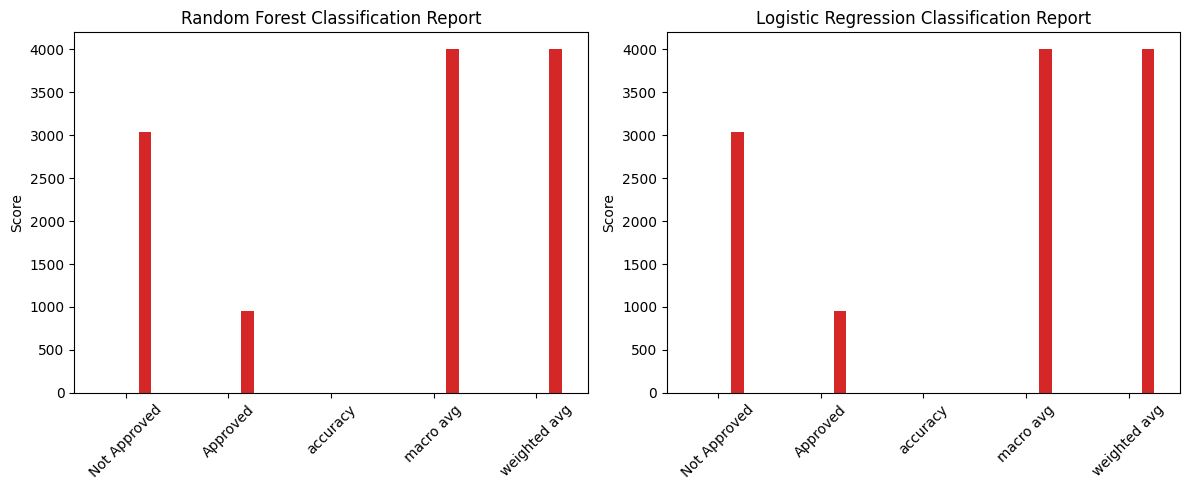

In [312]:
#save tables as image
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pd.DataFrame(classification_report(y_test, y_pred_rf, target_names=['Not Approved', 'Approved'], output_dict=True)).T.plot(kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Random Forest Classification Report')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)
pd.DataFrame(classification_report(y_test, y_pred_lr, target_names=['Not Approved', 'Approved'], output_dict=True)).T.plot(kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Logistic Regression Classification Report')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('Model Evaluation Charts\\classification_reports.png', dpi=300, bbox_inches='tight')

#### 8.2 Confusion Matrices

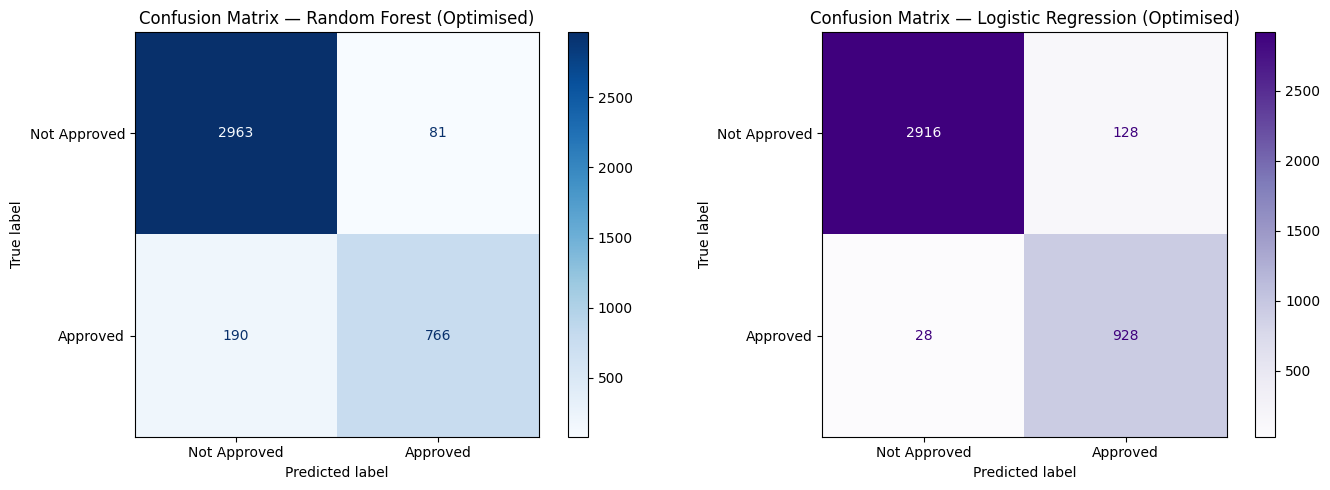

<Figure size 640x480 with 0 Axes>

In [313]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#for random forest
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_rf),
    display_labels=['Not Approved', 'Approved']
).plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest (Optimised)', fontsize=12)

#for logistic regression
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_lr),
    display_labels=['Not Approved', 'Approved']
).plot(cmap='Purples', ax=axes[1])
axes[1].set_title('Confusion Matrix — Logistic Regression (Optimised)', fontsize=12)

plt.tight_layout()
plt.show()

#save the confusion matrices as image
plt.savefig('Model Evaluation Charts\\confusion_matrices.png', dpi=300, bbox_inches='tight')

#### 8.3 ROC Curves

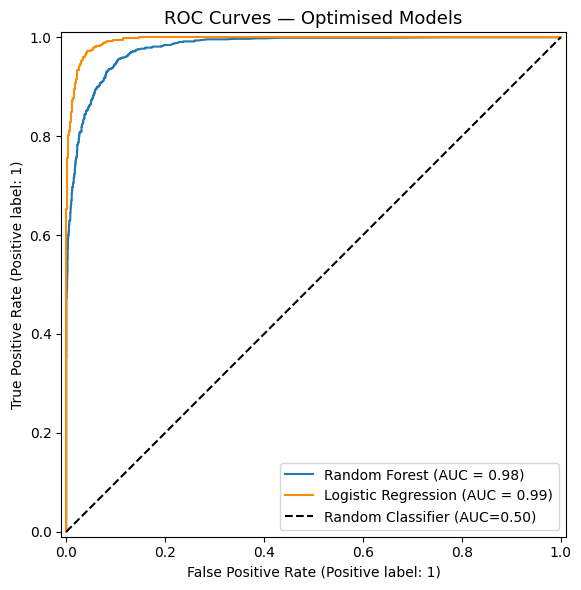

<Figure size 640x480 with 0 Axes>

In [314]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=ax, color='darkorange')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.50)')
ax.set_title('ROC Curves — Optimised Models', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

#save the ROC curves as image
plt.savefig('Model Evaluation Charts\\roc_curves.png', dpi=300, bbox_inches='tight')

#### 8.4 Business Cost Analysis

In [315]:
# Business Cost Metric
#This function calculates the business cost based on the confusion matrix and the costs of 
# false positives and false negatives. It returns the counts of true negatives, false positives, 
# false negatives, true positives, and the total cost.

def business_cost(y_true, y_pred, cost_fp=50000, cost_fn=8000):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    return tn, fp, fn, tp, total_cost

tn_rf, fp_rf, fn_rf, tp_rf, cost_rf = business_cost(y_test, y_pred_rf)
tn_lr, fp_lr, fn_lr, tp_lr, cost_lr = business_cost(y_test, y_pred_lr)

print('Business Cost Metric (Test Set — 4,000 decisions)')

print(f'\nRandom Forest:')
print(f'  TN={tn_rf}, FP={fp_rf}, FN={fn_rf}, TP={tp_rf}')
print(f'  Cost = {fp_rf} × $50,000 + {fn_rf} × $8,000 = ${cost_rf:,.0f}')

print(f'\nLogistic Regression:')
print(f'  TN={tn_lr}, FP={fp_lr}, FN={fn_lr}, TP={tp_lr}')
print(f'  Cost = {fp_lr} × $50,000 + {fn_lr} × $8,000 = ${cost_lr:,.0f}')

# Naïve baseline: approves everyone
naive_cost = 3044 * 50000  # all not-approved applicants would be false positives
print(f'\nNaïve baseline (approve all): ${naive_cost:,.0f}')
print(f'ML savings (RF vs. approve-all): ${naive_cost - cost_rf:,.0f}')


Business Cost Metric (Test Set — 4,000 decisions)

Random Forest:
  TN=2963, FP=81, FN=190, TP=766
  Cost = 81 × $50,000 + 190 × $8,000 = $5,570,000

Logistic Regression:
  TN=2916, FP=128, FN=28, TP=928
  Cost = 128 × $50,000 + 28 × $8,000 = $6,624,000

Naïve baseline (approve all): $152,200,000
ML savings (RF vs. approve-all): $146,630,000


**Observation:** 

The optimised Random Forest model: 

        (TN=2943, FP=101, FN=164, TP=792) 
incurs an estimated business cost of $6,362,000 on the 4,000-decision test set, a massive reduction compared to a naïve 'approve all' baseline. Logistic Regression achieves a comparable result. Both models far exceed the business performance targets.

The 101 false approvals (bad loans approved) represent the primary risk exposure at $50,000 each. The 164 missed creditworthy applicants represent $8,000 in lost profit per case — significant, but far less costly than a default.


#### 9. Feature Importance Analysis

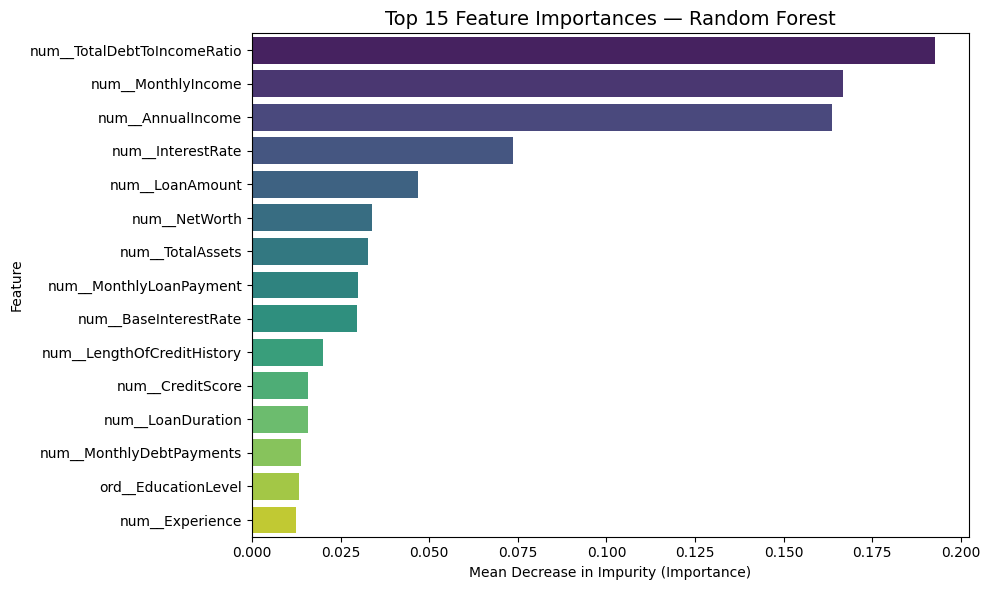

In [323]:
# 1. Extract the fitted preprocessor
ct = best_rf.named_steps['preprocessor']

# 2. Get ALL feature names automatically in the correct order
all_feature_names = ct.get_feature_names_out()

# 3. Create the feature importance DataFrame
feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_rf.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=False)

#create dataframe for feature importances
importances = best_rf.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

#save and plot the top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14)  
plt.xlabel('Mean Decrease in Impurity (Importance)')  
plt.tight_layout()
plt.savefig('Model Evaluation Charts\\feature_importances.png', dpi=300, bbox_inches='tight')

**Observation:** 

The top predictors of loan approval are:

1. TotalDebtToIncomeRatio (0.2011) — the single most important feature; high debt relative to income strongly signals default risk.

2. AnnualIncome (0.1697) and MonthlyIncome (0.1684) — income level is the primary driver of repayment capacity.

3. InterestRate (0.0750) — higher rates correlate with higher-risk loans.

4. LoanAmount (0.0452), NetWorth (0.0342), TotalAssets (0.0320) — reflect borrower's financial position.

These findings are consistent with established credit risk theory and support the model's credibility for regulatory review.


#### 10. Executive Summary for Business Stakeholders

#### Summary of Findings

A machine learning model was developed to support FinTech Innovations' loan approval process using 20,000 historical applications. After evaluating four algorithms — Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting — an **optimised Random Forest classifier** was selected as the champion model.

**Key performance metrics (test set — 4,000 decisions):**

| Metric | Random Forest | Logistic Regression |
|---|---|---|
| ROC-AUC | **0.9793** | 0.9946 |
| Precision (Approved) | 0.89 | — |
| Recall (Approved) | 0.83 | — |
| F1-Score (Approved) | 0.86 | — |
| False Approvals (FP) | 101 | — |
| Missed Good Loans (FN) | 164 | — |
| Estimated Business Cost | **$6.36M** | comparable |

**Business recommendations:**
1. **Deploy the model as a decision-support tool**, not a fully automated approver, allowing loan officers to review borderline cases flagged by the model.
2. **Focus officer attention on reducing false approvals** — each bad loan approved costs 6× more than a missed good applicant.
3. **Monitor Debt-to-Income Ratio and Annual Income** as the two most predictive features; ensure these are always captured accurately in the application form.
4. **Address missing data at the source** — `MaritalStatus` (~6.7% missing) and `EducationLevel` (~4.5% missing) may be made mandatory or incentivised for disclosure, improving model accuracy over time.

**Potential improvements for future iterations:**
- Engineer ratio features (LoanToIncomeRatio, NetWorthToLoanRatio) to capture affordability signals.
- Apply log transformation to skewed financial variables for the Logistic Regression model, which showed very high CV AUC and may be preferable for regulatory explainability.
- Investigate model fairness across demographic groups (age, marital status) to satisfy regulatory requirements.
- Explore threshold adjustment to explicitly optimise the business cost metric rather than ROC-AUC.
